In [1]:
%load_ext autoreload
%autoreload 2

In [18]:
import lightshowai as ls
from lightshowai.postprocess.broaden import SiteSpectrum
import matplotlib as mpl
import matplotlib.pyplot as pyplot

from scipy.stats import pearsonr, spearmanr
from scipy import optimize
from scipy.interpolate import InterpolatedUnivariateSpline
from lightshowai.postprocess.compare_utils import cos_similar
import copy
import numpy as np
import scipy
from typing import Tuple

In [47]:
import re
def parseExptSpectrumXdi(filename):
    e=[]
    spectrum = []
    with open(filename, 'r') as f:
        active=False
        for line in f:
            line=line.strip()
            if re.match(r'#\s+energy',line) != None:
                active = True
                #print("Active",line)
            elif active:
                #print("Data",line)
                cols = line.split()                
                if(len(cols) == 7):
                    #print(cols[0],cols[1])
                    e.append(float(cols[0]))
                    spectrum.append(float(cols[3]))  #mutrans

    return np.vstack( (e, spectrum) ).T                    

prenorm_spec = parseExptSpectrumXdi("Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Anatase.xdi")

    

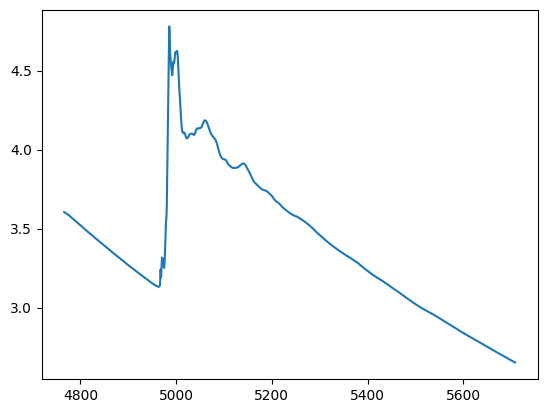

In [48]:
pyplot.plot(prenorm_spec[:,0], prenorm_spec[:,1])

dE smallest 0.24000000000069122
grid dE 0.2400216560508852 endpoints 4765.993 5708.078 vs orig endpoints 4765.993 5708.078


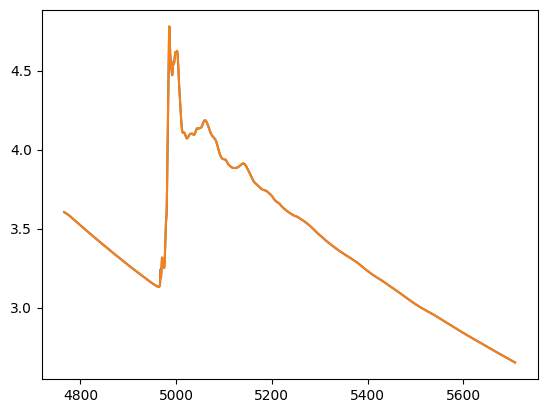

In [5]:
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
import math

def smoothSpectrum(spect, smooth_width_eV=1.0):
    e = spect[:,0]
    mu = spect[:,1]

    #Filter takes a number of points in the smoothing window, not a smoothing size
    #As the expt spectrum does not have a uniform energy spacing we must first interpolate to a 
    #fixed-spacing grid
    dE = e[1]-e[0]
    for i in range(1,len(e)):
        dE_cur = e[i] - e[i-1]
        dE = min(dE, dE_cur)
    print("dE smallest", dE)
    
    num = int(math.floor( (e[-1] - e[0])/dE ) ) + 1
    grid = np.linspace(e[0],e[-1],num=num, endpoint=True)
    dE = grid[1]-grid[0]
    print("grid dE",dE,"endpoints",grid[0],grid[-1],"vs orig endpoints", e[0],e[-1])

    ius = interp1d(
        e, mu,        
        assume_sorted=True,
        kind="cubic",
        bounds_error=False,
    )
    mu_grid = ius(grid)
        
    window_pts = int(round(smooth_width_eV / dE))
    window_pts = window_pts + (1 if (window_pts %2 == 0) else 0)

    mu_smooth = savgol_filter(mu_grid, window_pts, polyorder=3)
    return np.vstack( (grid, mu_smooth) ).T    

prenorm_spec_smooth = smoothSpectrum(prenorm_spec, 1)

pyplot.plot(prenorm_spec[:,0], prenorm_spec[:,1])
pyplot.plot(prenorm_spec_smooth[:,0], prenorm_spec_smooth[:,1])


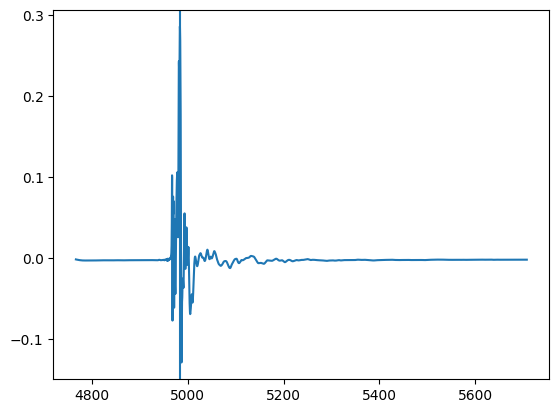

In [6]:
#Find edge by finding maximum of derivative
dmu_dE = np.gradient(prenorm_spec_smooth[:,1], prenorm_spec_smooth[:,0])
edge_E = prenorm_spec_smooth[np.argmax(dmu_dE),0]

pyplot.plot(prenorm_spec_smooth[:,0], dmu_dE)
pyplot.axvline(edge_E)

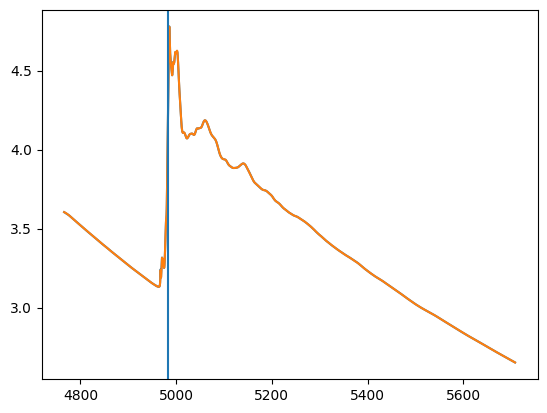

In [7]:
pyplot.plot(prenorm_spec[:,0], prenorm_spec[:,1])
pyplot.plot(prenorm_spec_smooth[:,0], prenorm_spec_smooth[:,1])
pyplot.axvline(edge_E)

(4765.993, 5000.0)

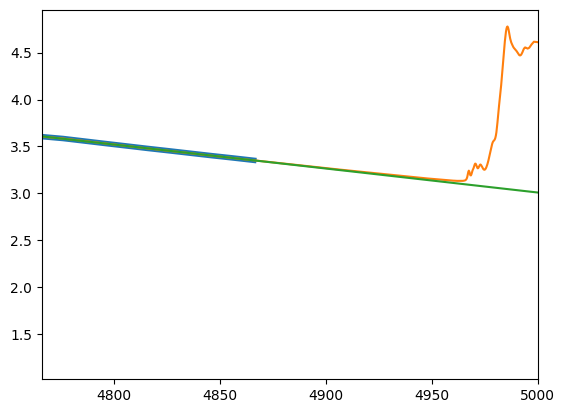

In [8]:
#Choose upper bound of pre-edge fit range as halfway between the start and the edge
energy= prenorm_spec[:,0]
ubound_E = (energy[0] + edge_E)/2

ubound_idx = np.argmin( np.abs(energy - ubound_E) )

p = np.polyfit(prenorm_spec[:ubound_idx,0], prenorm_spec[:ubound_idx,1], 1)

preedge = p[0] * energy + p[1]

pyplot.plot(prenorm_spec[:ubound_idx,0], prenorm_spec[:ubound_idx,1],lw=4)
pyplot.plot(prenorm_spec[:,0], prenorm_spec[:,1])
pyplot.plot(energy, preedge)
pyplot.xlim(energy[0],5000)

Fit range 5007.646 5708.078 energy range 700.4320000000007 degree 2


(4923.212598726115, 5708.078)

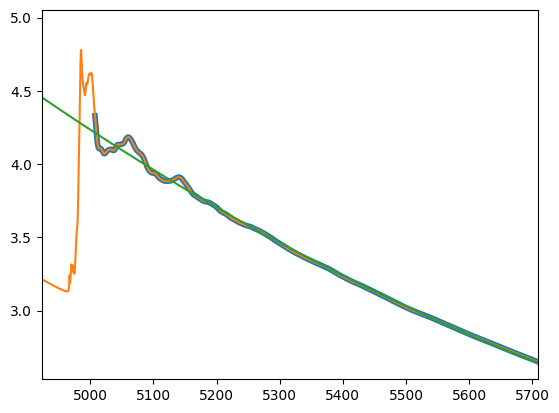

In [12]:
#For post-edge fit, xraylarch uses the lower bound as lbound = min(e0+25, e0+  (emax-e0)/3 ) and 
#polynomial order nnorm = 2 in emax-lbound>300, 1 if emax-lbound>30, or 0 if less.
#e0 is the edge location
dlbound = (energy[-1] - edge_E)/3
dlbound = min(dlbound, 25) #25 seems pretty close to me, but this is what they use

lbound_E = edge_E + dlbound
lbound_idx=np.argmin( np.abs(energy - lbound_E) )
lbound_E = energy[lbound_idx]

frange = energy[-1] - lbound_E

if frange >= 300:
    nnorm=2
elif frange >= 30:
    nnorm=1
else:
    nnorm=0

print("Fit range",lbound_E, energy[-1], "energy range", energy[-1] - lbound_E, "degree", nnorm)

p = np.polyfit(prenorm_spec[lbound_idx:,0], prenorm_spec[lbound_idx:,1], nnorm)

if nnorm == 0:
    postedge = p[0]
elif nnorm == 1:
    postedge = p[0]*energy + p[1]
else:
    postedge = p[0]*energy**2 + p[1]*energy + p[2]


pyplot.plot(prenorm_spec[lbound_idx:,0], prenorm_spec[lbound_idx:,1],lw=4)
pyplot.plot(prenorm_spec[:,0], prenorm_spec[:,1])
pyplot.plot(energy, postedge)
pyplot.xlim(edge_E-60, energy[-1])


In [13]:
edge_idx = np.argmin( np.abs(energy - edge_E) )
edge_step = postedge[edge_idx] - preedge[edge_idx]
edge_step = max(1.e-12, abs(float(edge_step)))
print("edge step", edge_step)

edge step 1.2325190197232345


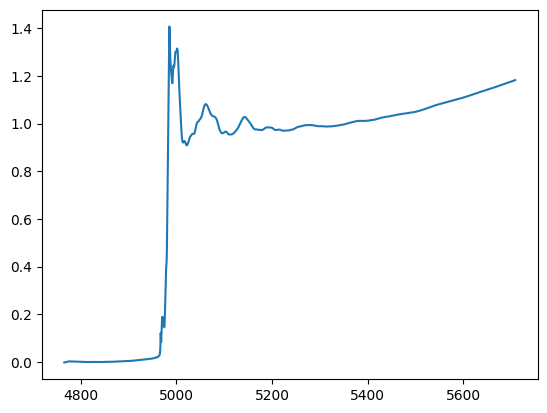

In [14]:
spec_sub = prenorm_spec.copy()
spec_sub[:,1] = (spec_sub[:,1] - preedge)/edge_step

pyplot.plot(spec_sub[:,0], spec_sub[:,1])

In [41]:
#Test the library-packaged result of this investigation
from lightshowai.postprocess.normalize import normalizeSpectrum

Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-CaCe2Ti4O12.xdi
Pre-edge fit range 4765.997 4876.006 width 110.00900000000001 degree 1
Post-edge fit range 5007.644 5708.08 width 700.4359999999997 degree 2
Edge step 1547.4537193992048


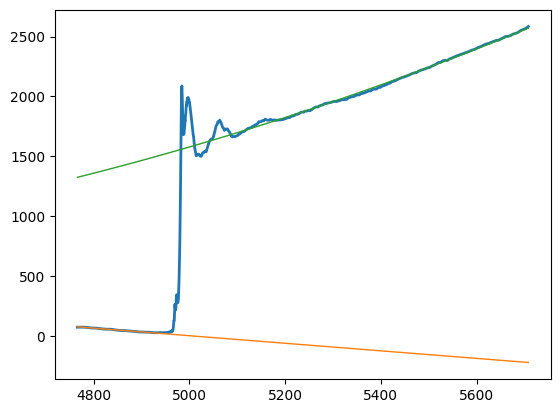

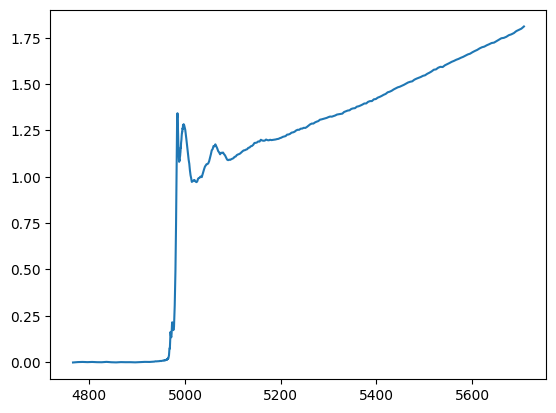



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Rutile.xdi
Pre-edge fit range 4765.985 4876.009 width 110.02400000000034 degree 1
Post-edge fit range 5008.917 5708.08 width 699.1629999999996 degree 2
Edge step 1.6237187898330028


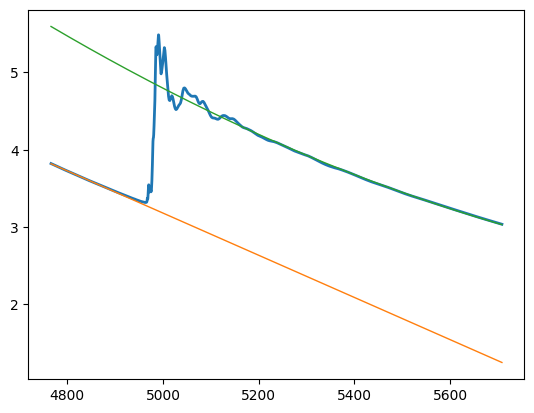

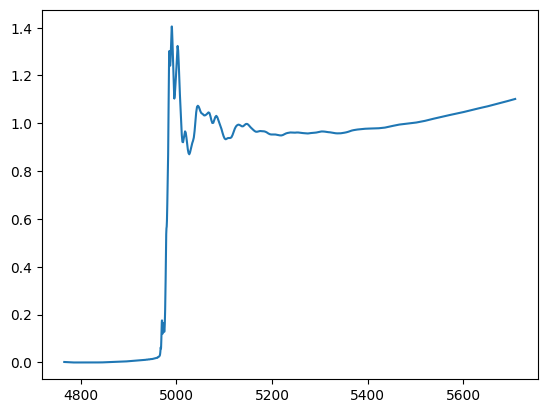



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Anatase.xdi
Pre-edge fit range 4765.993 4876.002 width 110.00900000000001 degree 1
Post-edge fit range 5007.646 5708.078 width 700.4320000000007 degree 2
Edge step 1.2324233319767117


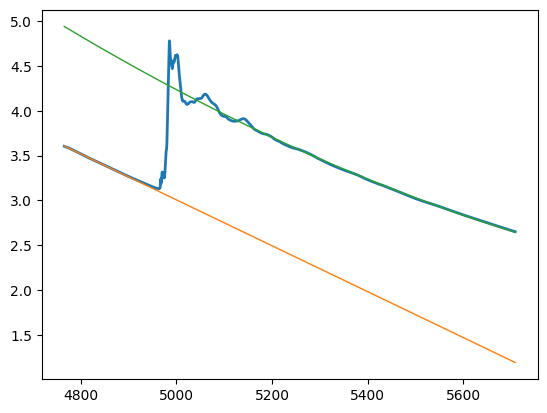

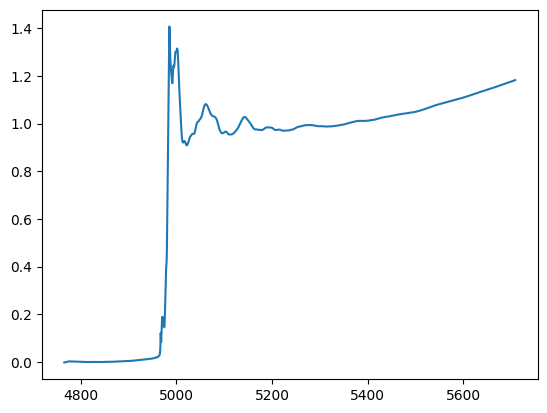



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Gd2TiO5.xdi
Pre-edge fit range 4765.997 4866.008 width 100.01099999999951 degree 1
Post-edge fit range 4993.004 5708.082 width 715.0780000000004 degree 2
Edge step 0.14570946485899405


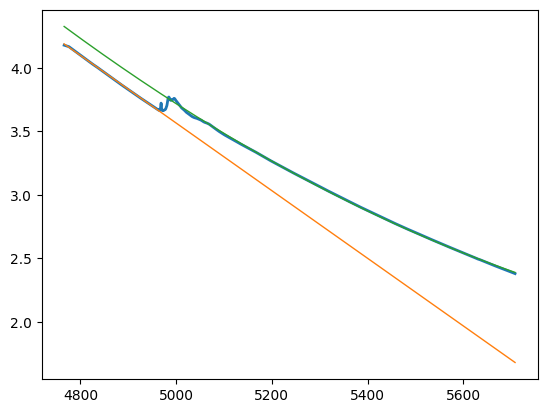

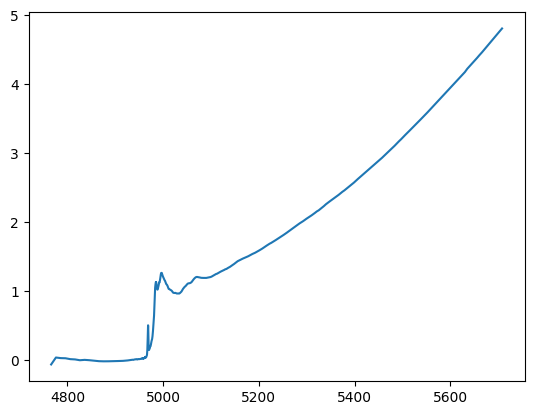



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Eu2Ti2O7.xdi
Pre-edge fit range 4765.994 4876.008 width 110.01400000000012 degree 1
Post-edge fit range 5007.645 5818.23 width 810.5849999999991 degree 2
Edge step 0.2331784857207051


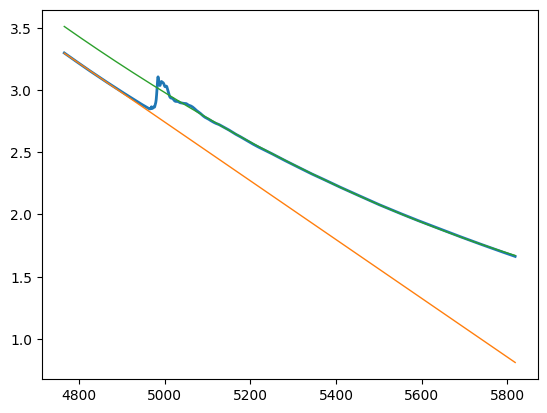

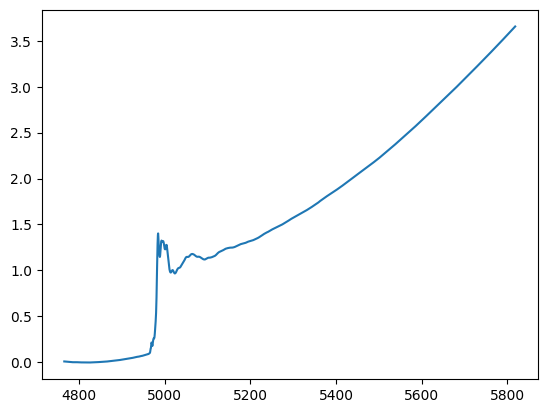



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-CaTiO3.xdi
Pre-edge fit range 4765.984 4876.005 width 110.02099999999973 degree 1
Post-edge fit range 5007.646 5708.081 width 700.4350000000004 degree 2
Edge step 0.3683911445521435


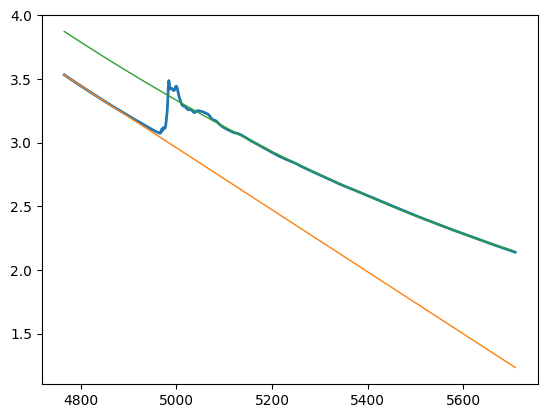

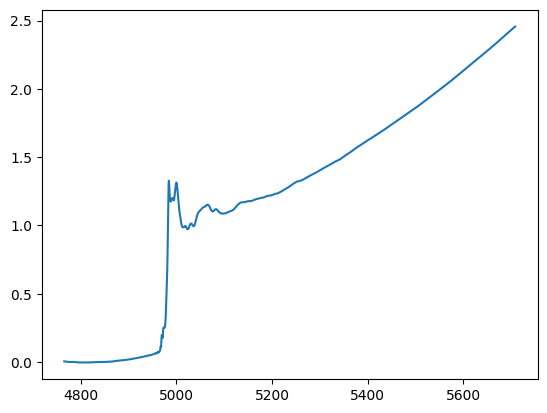



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Brookite.xdi
Pre-edge fit range 4765.995 4876.012 width 110.01699999999983 degree 1
Post-edge fit range 5007.647 5708.082 width 700.4350000000004 degree 2
Edge step 1.103101605271327


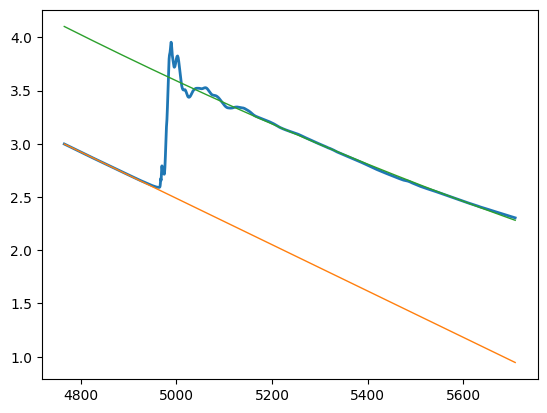

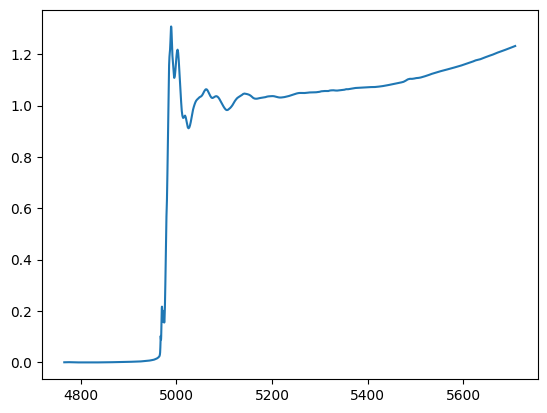



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-EuTiO3.xdi
Pre-edge fit range 4765.994 4876.007 width 110.01299999999992 degree 1
Post-edge fit range 5007.646 5818.231 width 810.585 degree 2
Edge step 0.15973588809066008


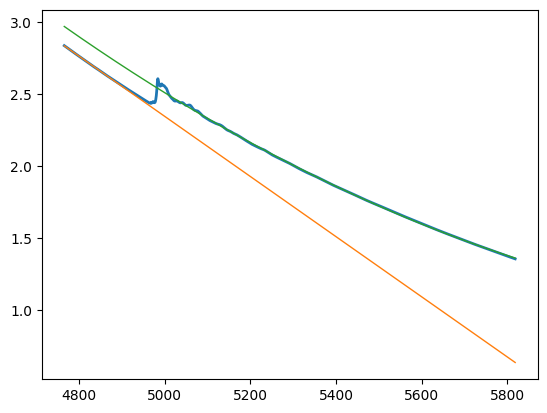

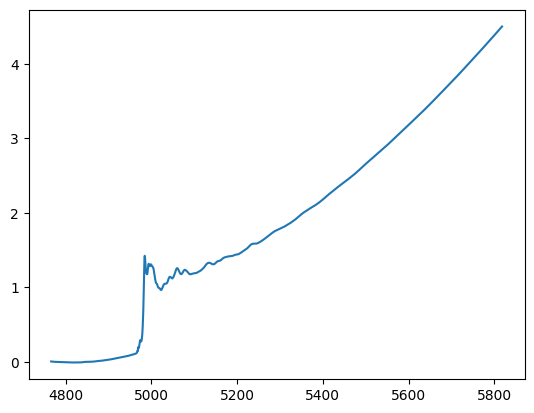



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Titanite.xdi
Pre-edge fit range 4865.992 4926.003 width 60.01099999999951 degree 1
Post-edge fit range 5008.007 5164.002 width 155.9950000000008 degree 1
Edge step 0.10773202672304905


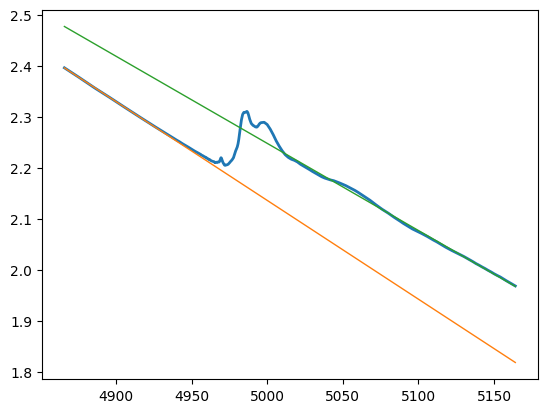

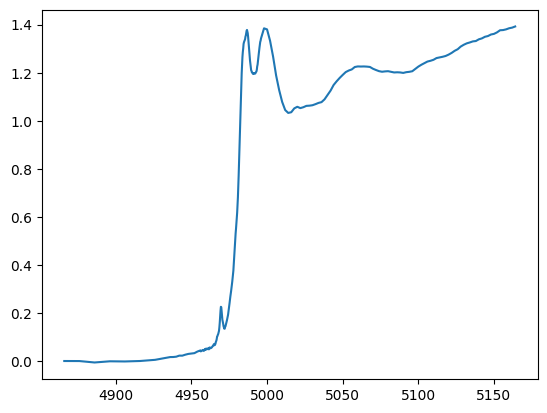



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-CaZrTi2O7.xdi
Pre-edge fit range 4765.997 4876.007 width 110.00999999999931 degree 1
Post-edge fit range 5007.648 5708.082 width 700.4340000000002 degree 2
Edge step 0.20445701056338272


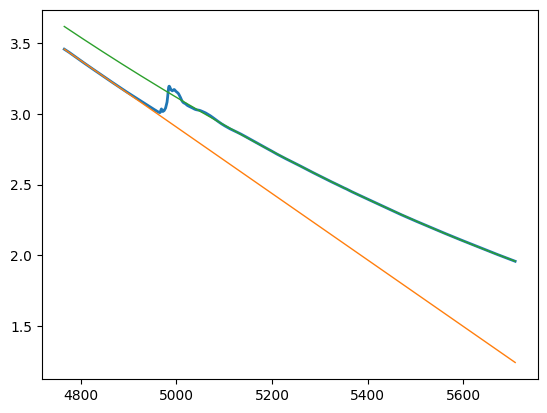

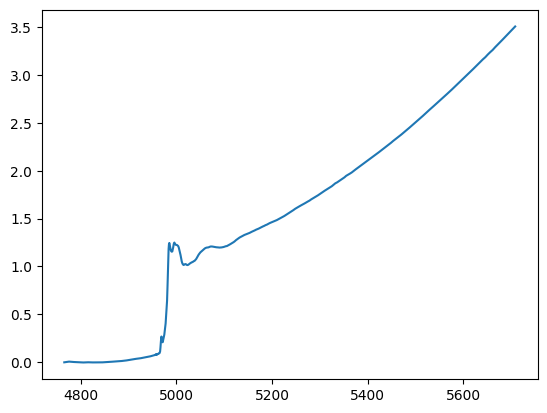



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-BaTiO3.xdi
Pre-edge fit range 4765.982 5006.399 width 240.41700000000037 degree 1
Post-edge fit range 5271.601 5708.08 width 436.47900000000027 degree 2
Edge step 0.23258394871235222


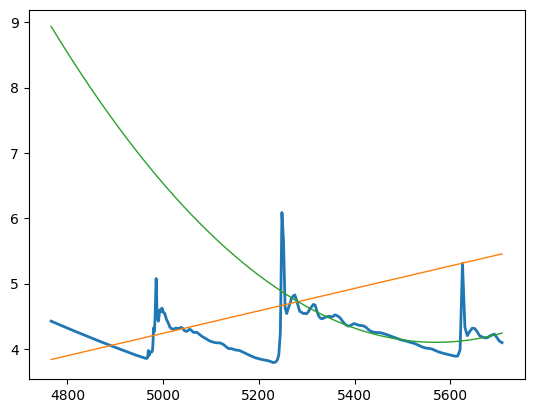

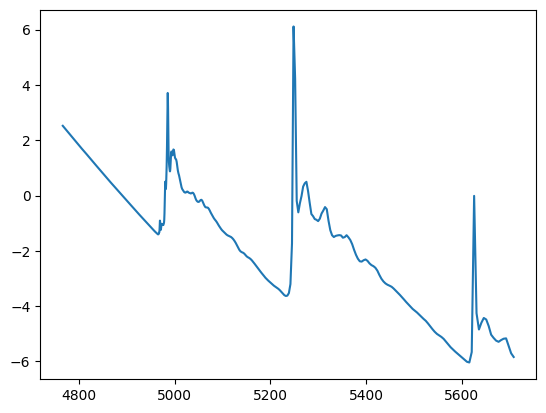



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-BATO16.xdi
Pre-edge fit range 4765.99 4876.002 width 110.01200000000063 degree 1
Post-edge fit range 5002.766 5708.08 width 705.3140000000003 degree 2
Edge step 0.6504007662118347


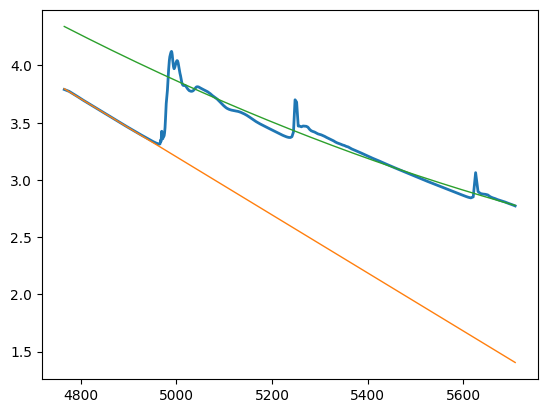

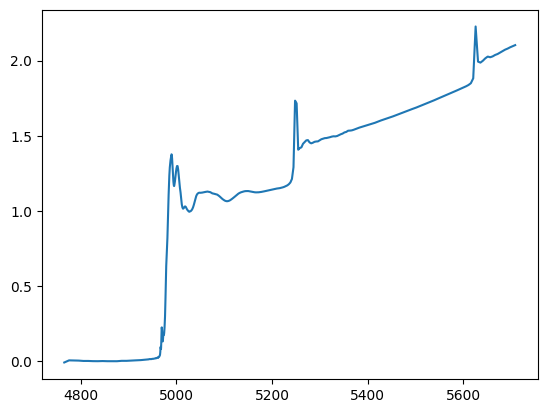



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Ce067TiO3.xdi
Pre-edge fit range 4765.999 4876.005 width 110.00600000000031 degree 1
Post-edge fit range 5006.398 5708.08 width 701.6819999999998 degree 2
Edge step 0.4594166177299748


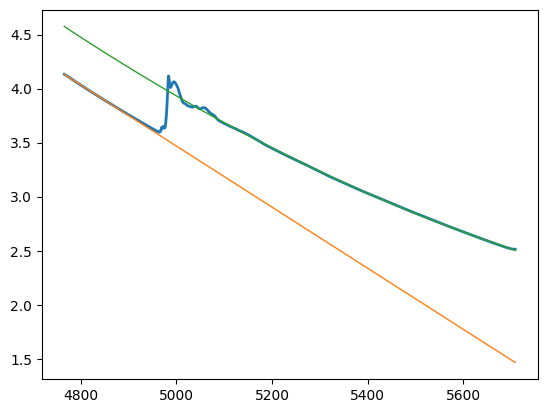

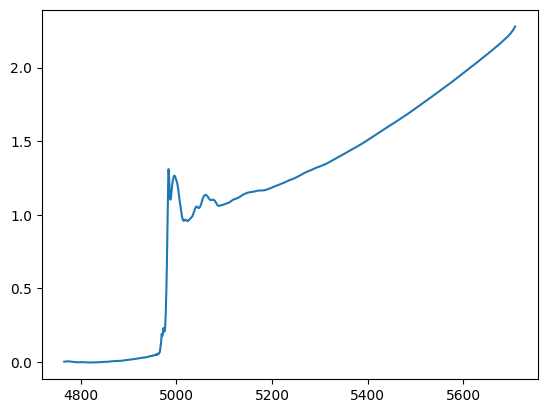



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Ce2Ti2O7.xdi
Pre-edge fit range 4765.991 4876.001 width 110.01000000000022 degree 1
Post-edge fit range 5005.167 5708.08 width 702.9129999999996 degree 2
Edge step 1069.7843153890012


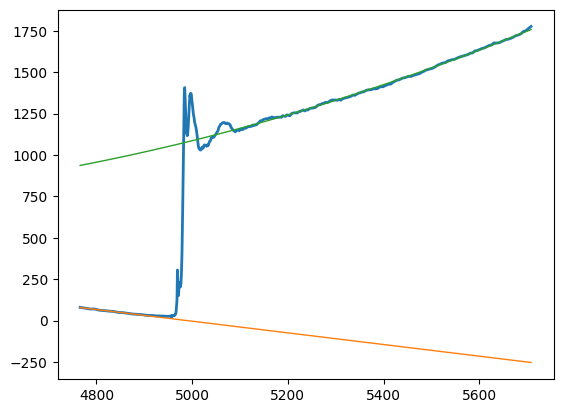

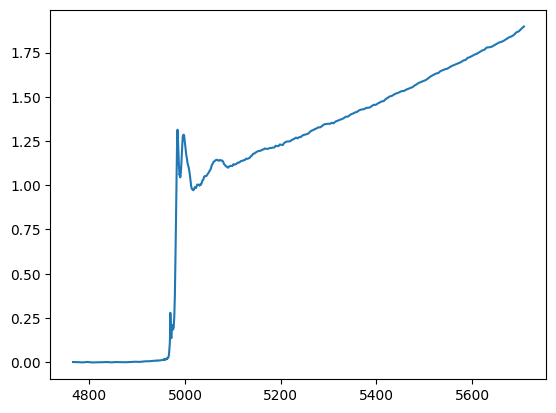



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Fe2TiO5.xdi
Pre-edge fit range 4765.992 4876.005 width 110.01299999999992 degree 1
Post-edge fit range 5006.399 5708.078 width 701.6790000000001 degree 2
Edge step 0.4349190526894855


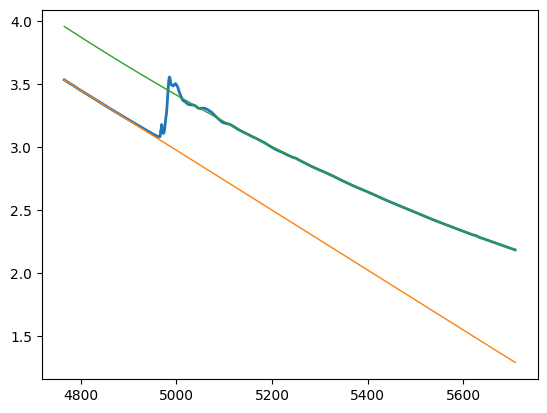

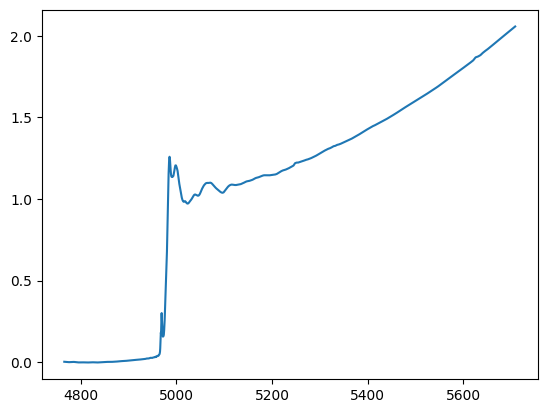



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-SrCe2Ti4O12.xdi
Pre-edge fit range 4765.997 4876.009 width 110.01199999999972 degree 1
Post-edge fit range 5006.399 5708.08 width 701.6809999999996 degree 2
Edge step 1836.3276506065447


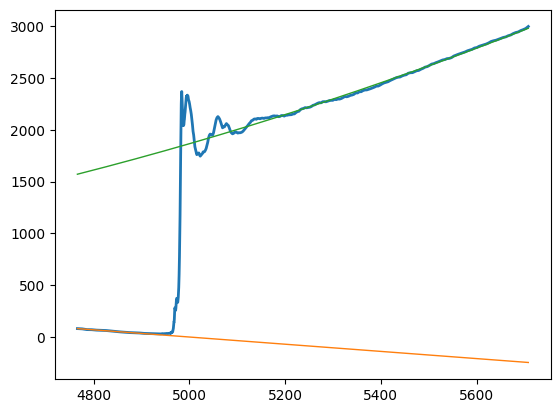

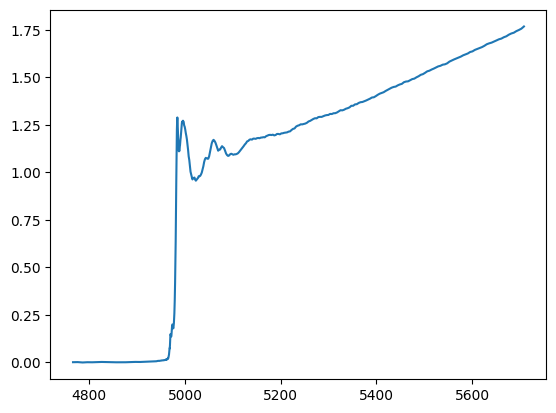



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-TitaniumFoil.xdi
Pre-edge fit range 4766.411 4866.405 width 99.99399999999969 degree 1
Post-edge fit range 4990.304 5819.242 width 828.9380000000001 degree 2
Edge step 1.977225078940858


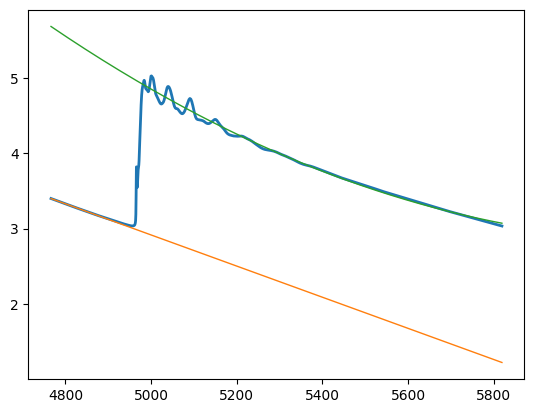

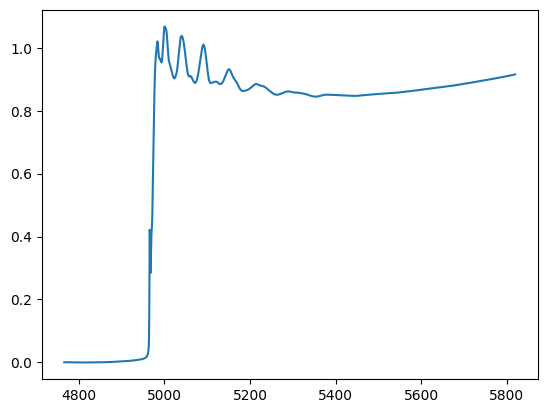



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Bi2Ce2Ti3O12.xdi
Pre-edge fit range 4765.997 4876.01 width 110.01299999999992 degree 1
Post-edge fit range 5006.399 5708.078 width 701.6790000000001 degree 2
Edge step 512.5912037263683


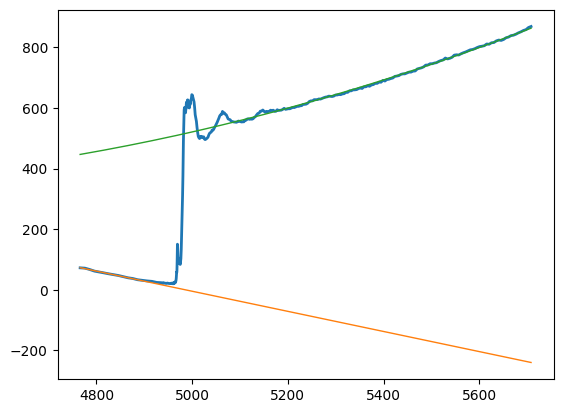

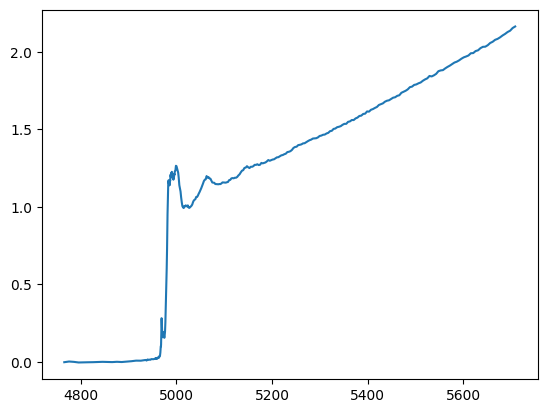



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Ni2TiO4.xdi
Pre-edge fit range 4765.998 4866.004 width 100.00600000000031 degree 1
Post-edge fit range 4992.752 5708.08 width 715.3279999999995 degree 2
Edge step 0.4253684712055268


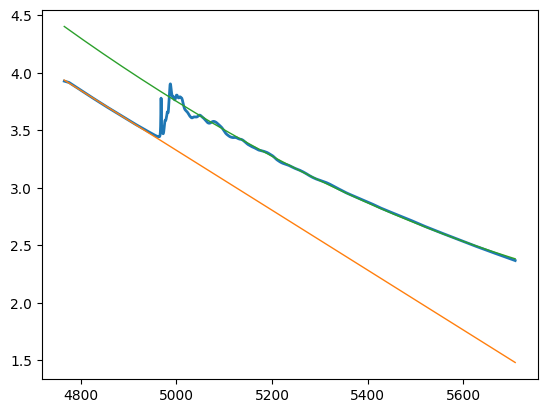

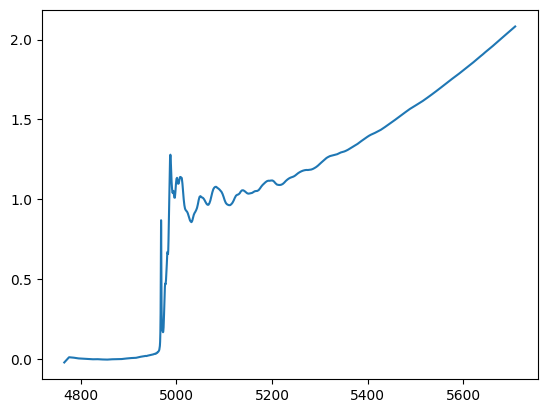



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Gd2TiO7.xdi
Pre-edge fit range 4765.994 4876.01 width 110.01600000000053 degree 1
Post-edge fit range 5006.399 5708.077 width 701.6779999999999 degree 2
Edge step 0.08117047156733115


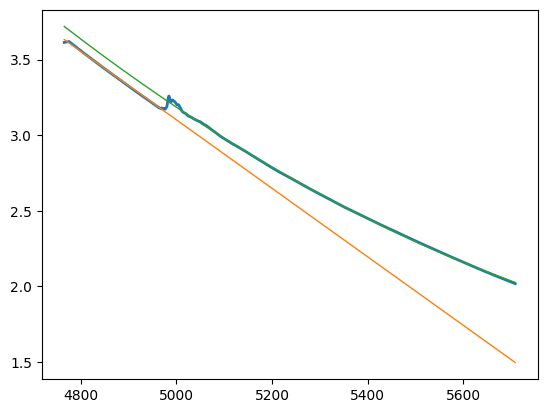

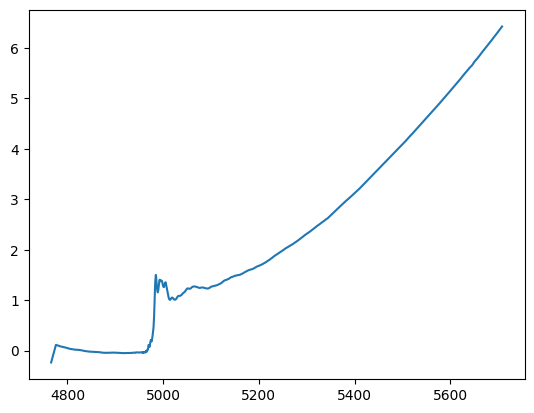



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-CeTi2O6.xdi
Pre-edge fit range 4765.998 4876.005 width 110.00700000000052 degree 1
Post-edge fit range 5007.648 5708.08 width 700.4319999999998 degree 2
Edge step 2100.8316781590074


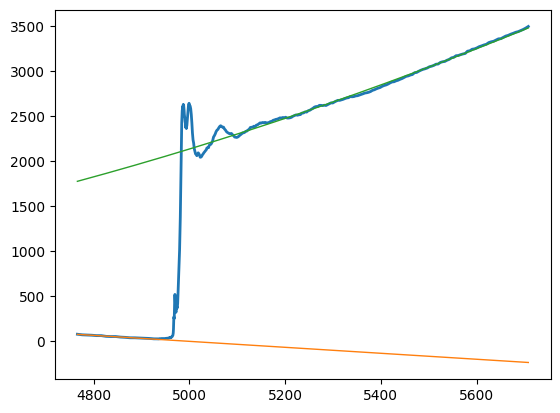

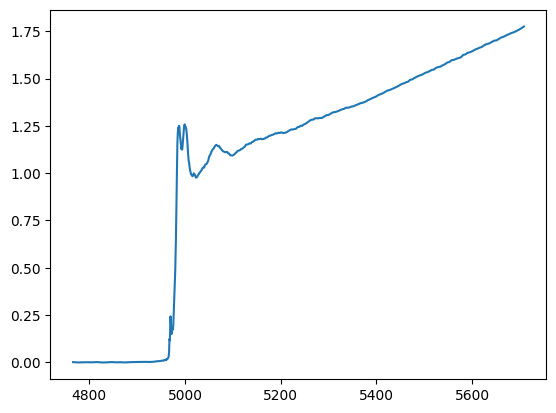



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-TiO.xdi
Pre-edge fit range 4765.997 4866.008 width 100.01099999999951 degree 1
Post-edge fit range 4996.001 5708.078 width 712.0770000000002 degree 2
Edge step 1.3392180267499683


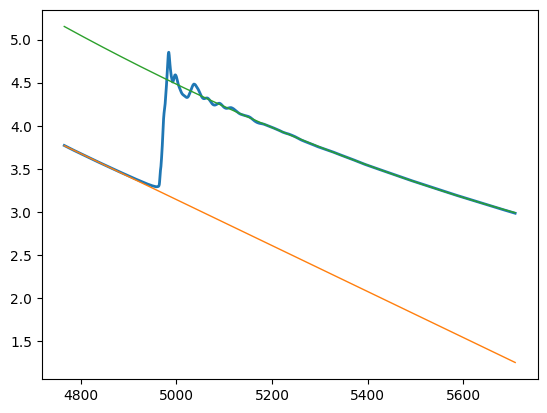

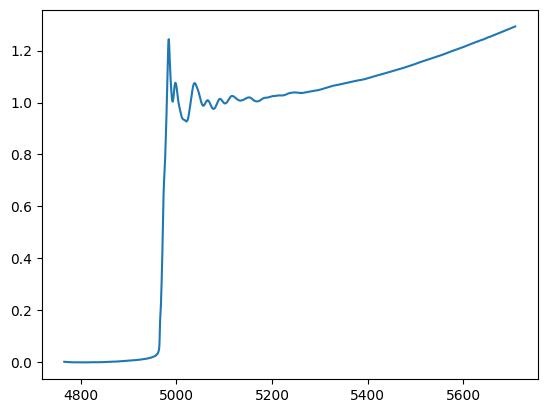



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-NiTiO3.xdi
Pre-edge fit range 4765.98 4866.007 width 100.02700000000004 degree 1
Post-edge fit range 4993.753 5708.078 width 714.3250000000007 degree 2
Edge step 0.5909525967285685


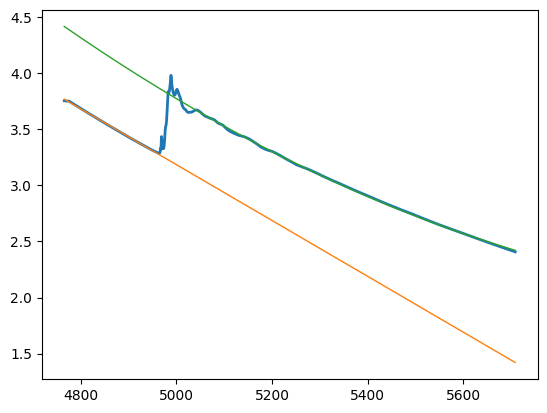

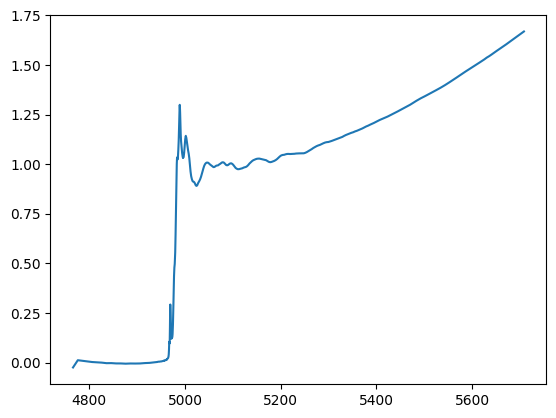



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Na2Ti3O7.xdi
Pre-edge fit range 4765.998 4866.008 width 100.01000000000022 degree 1
Post-edge fit range 4993.751 5708.08 width 714.3289999999997 degree 2
Edge step 0.8134414599600301


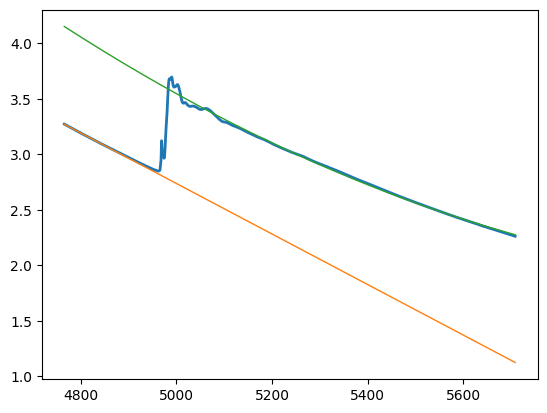

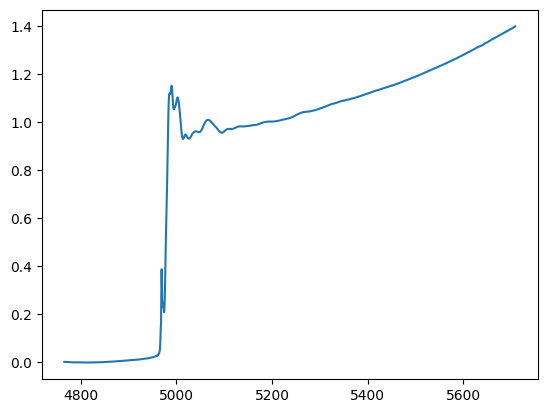



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-FeTiO3.xdi
Pre-edge fit range 4765.98 4866.012 width 100.03200000000015 degree 1
Post-edge fit range 4993.504 5708.078 width 714.5740000000005 degree 2
Edge step 0.8557299751959633


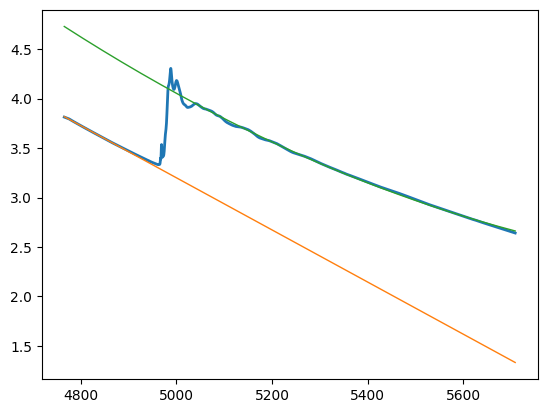

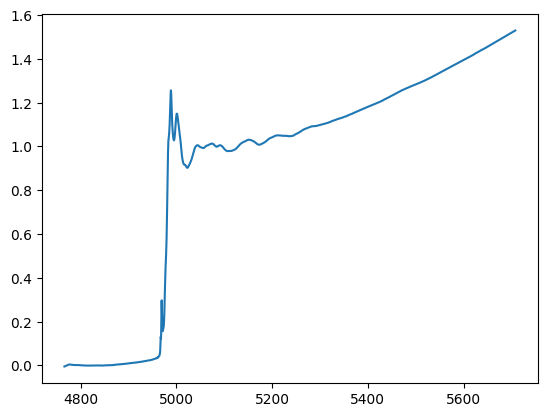



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Nd2Ti2O7.xdi
Pre-edge fit range 4765.991 4876.003 width 110.01199999999972 degree 1
Post-edge fit range 5006.398 5708.077 width 701.6790000000001 degree 2
Edge step 0.14417832887595772


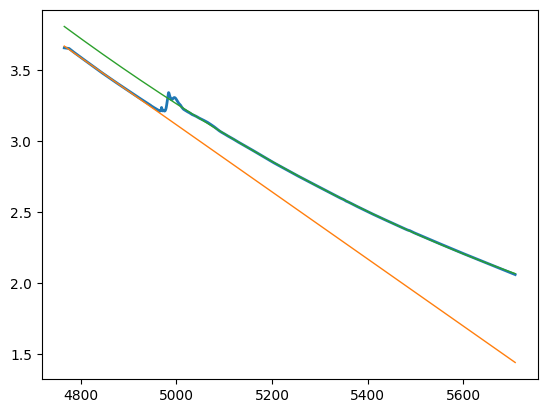

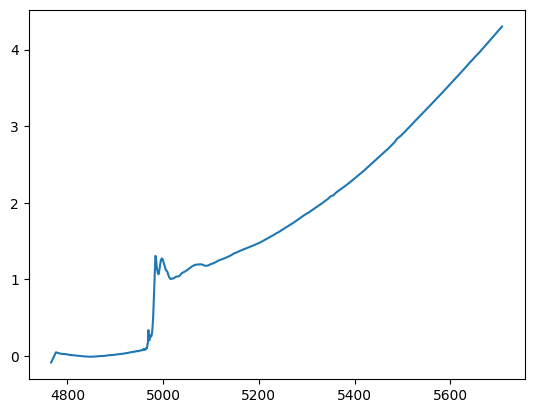



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Ti2O3.xdi
Pre-edge fit range 4765.998 4866.008 width 100.01000000000022 degree 1
Post-edge fit range 4999.296 5708.08 width 708.7839999999997 degree 2
Edge step 1.9431930208318402


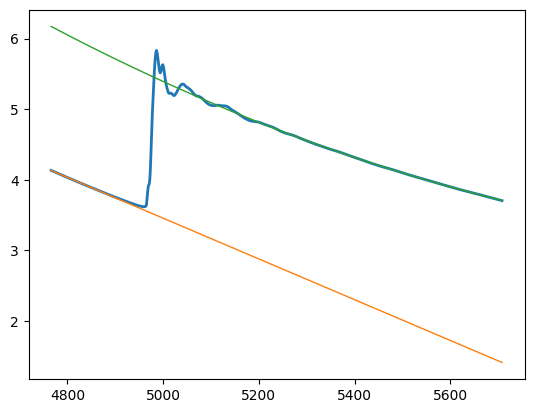

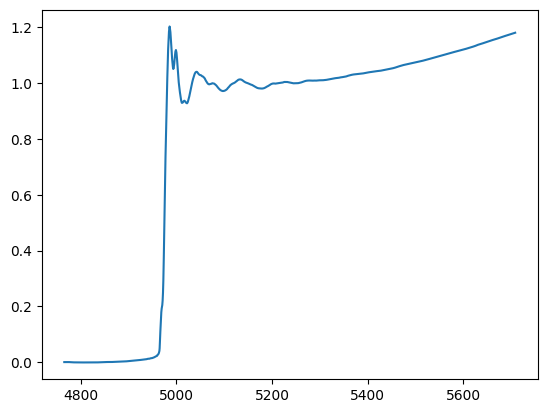



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Dy2TiO5.xdi
Pre-edge fit range 4765.994 4876.006 width 110.01200000000063 degree 1
Post-edge fit range 5007.648 5708.081 width 700.433 degree 2
Edge step 0.09968524247381616


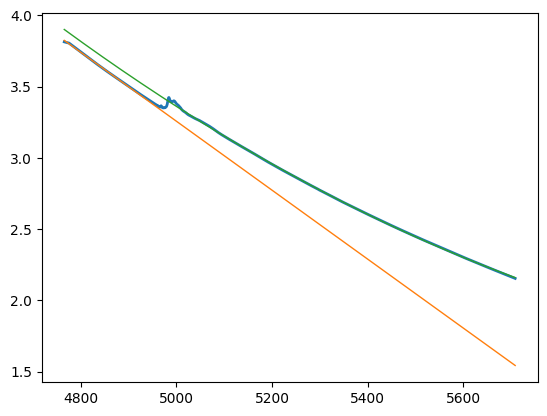

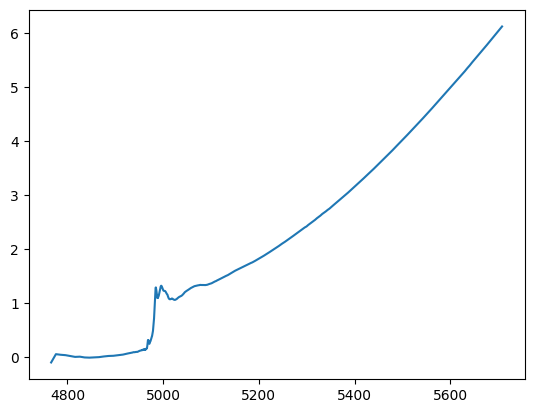



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-TiN.xdi
Pre-edge fit range 4765.993 4876.0 width 110.0069999999996 degree 1
Post-edge fit range 5005.163 5818.228 width 813.0650000000005 degree 2
Edge step 0.3403433746481035


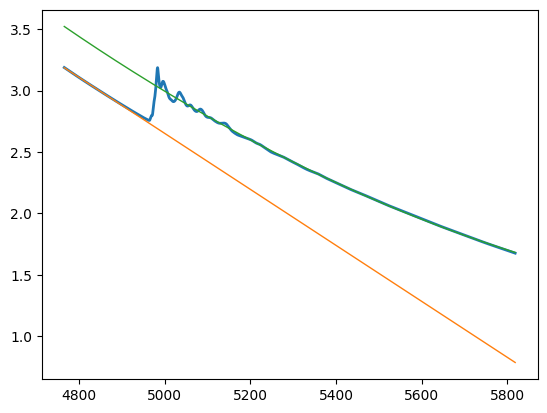

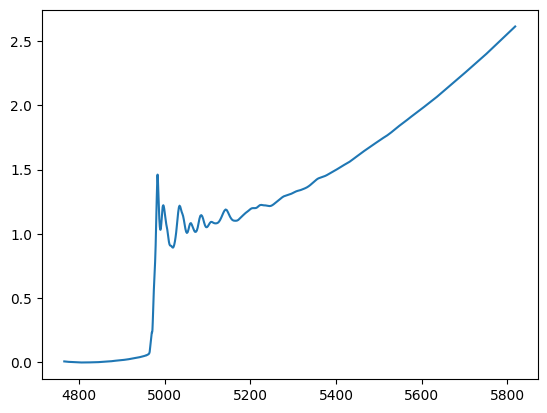



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-SrTiO3.xdi
Pre-edge fit range 4765.982 4876.01 width 110.02800000000025 degree 1
Post-edge fit range 5006.398 5708.08 width 701.6819999999998 degree 2
Edge step 0.4213026193943161


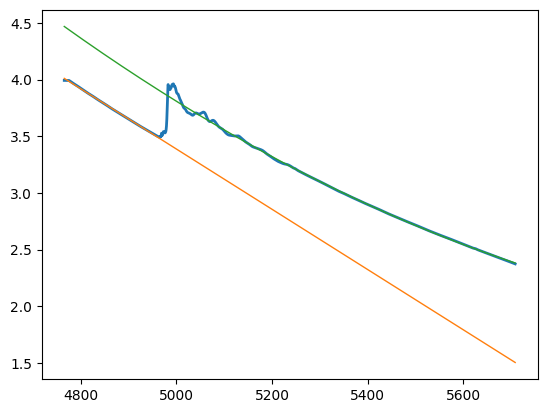

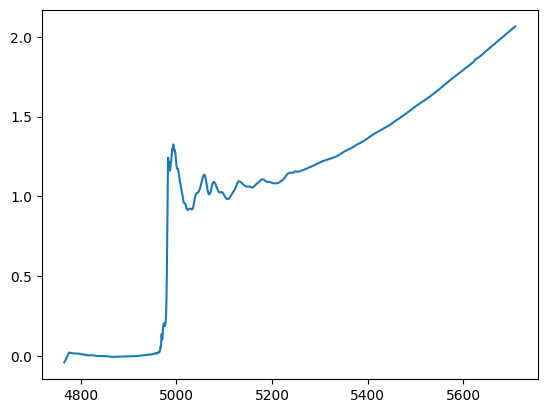



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Fresnoite.xdi
Pre-edge fit range 4765.989 5006.397 width 240.40800000000036 degree 1
Post-edge fit range 5271.602 5708.082 width 436.4800000000005 degree 2
Edge step 0.6087255758394532


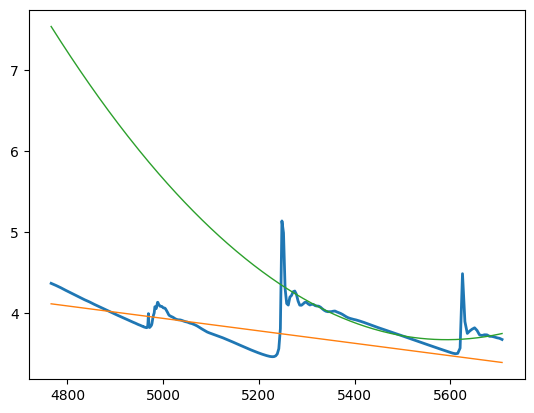

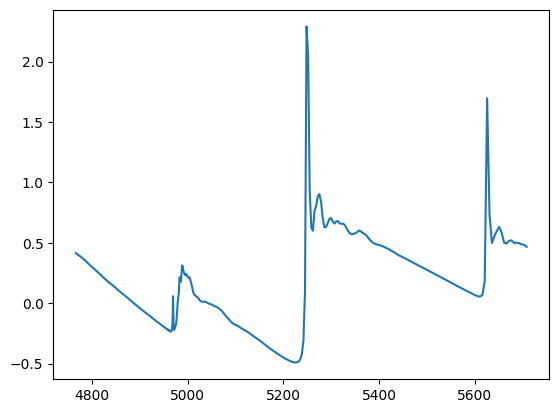



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Ce23TiO3.xdi
Pre-edge fit range 4765.993 4876.005 width 110.01199999999972 degree 1
Post-edge fit range 5005.168 5708.08 width 702.9120000000003 degree 2
Edge step 1401.029865055822


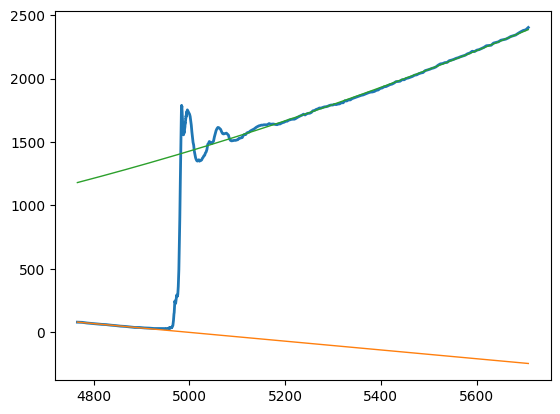

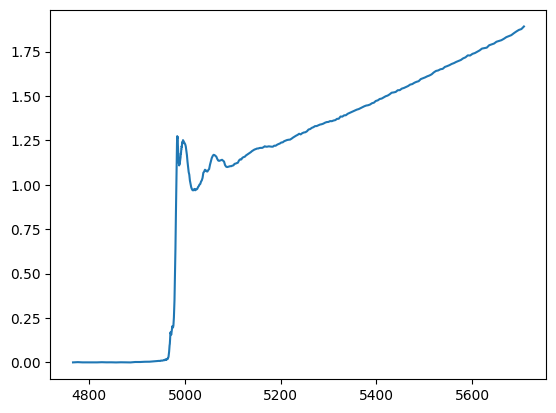



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Li2TiO5.xdi
Pre-edge fit range 4765.995 4866.012 width 100.01699999999983 degree 1
Post-edge fit range 5000.438 5818.231 width 817.7929999999997 degree 2
Edge step 1.0787580243916395


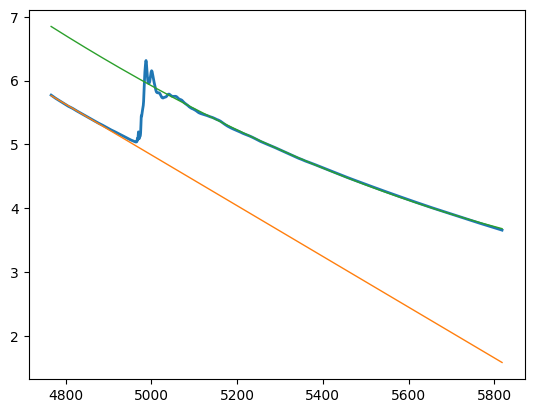

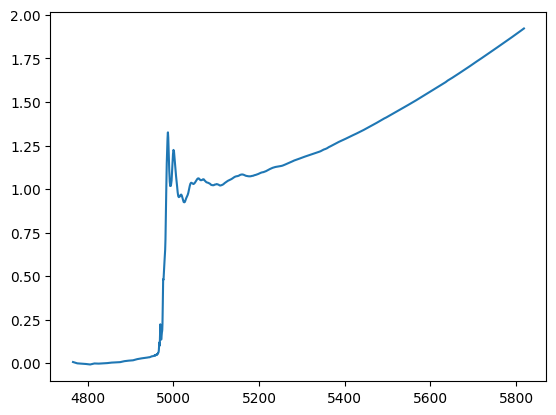



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-BFTO16.xdi
Pre-edge fit range 4765.998 5006.397 width 240.39900000000034 degree 1
Post-edge fit range 5271.598 5708.08 width 436.48199999999997 degree 2
Edge step 0.6049898017878315


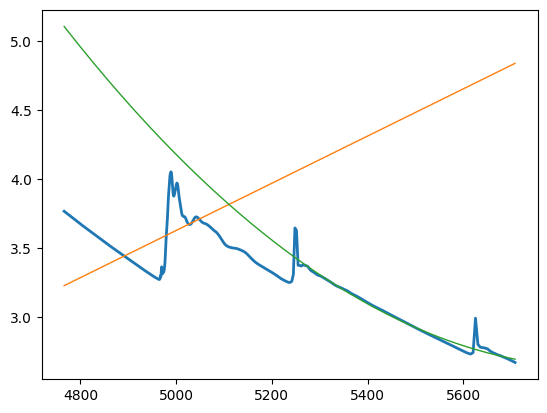

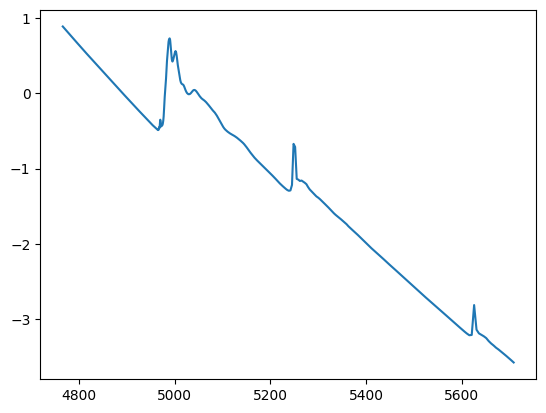

In [42]:
#Test for a bunch of other data
import glob
files = glob.glob("Bruce-prenorm/bmm-standards/Data/Ti/*.xdi")

for f in files:
    print(f)
    prenorm_spec = parseExptSpectrumXdi(f)
    norm_spec, pre, post = normalizeSpectrum(prenorm_spec,output_curves=True)
    pyplot.plot(prenorm_spec[:,0],prenorm_spec[:,1], lw=2)
    pyplot.plot(prenorm_spec[:,0],pre,lw=1)
    pyplot.plot(prenorm_spec[:,0],post,lw=1)
    pyplot.show()

    pyplot.plot(norm_spec[:,0],norm_spec[:,1])
    pyplot.show()
    print("================\n\n")

Pre-edge fit range 4796.007 4896.0 width 99.9930000000004 degree 1
Post-edge fit range 5007.646 5708.078 width 700.4320000000007 degree 2
Edge step 1.2280160982122954


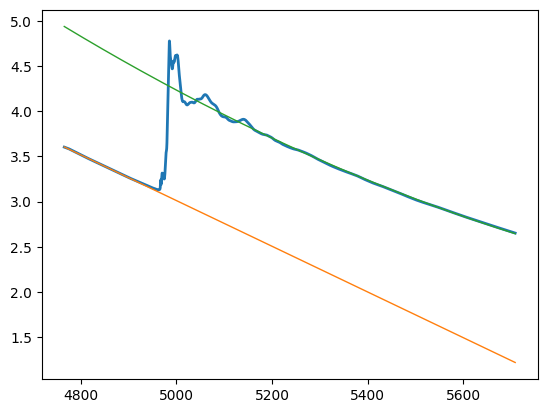

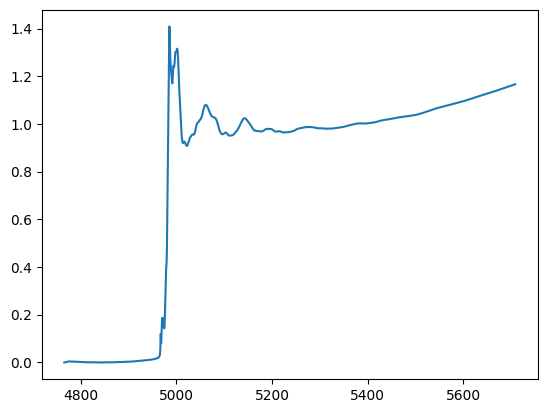

In [43]:
#Test the manual fit ranges (note that the actual fit range is adjusted to the nearest points in the dataset)
prenorm_spec = parseExptSpectrumXdi("Bruce-prenorm/Ti-K-Anatase.xdi")
norm_spec, pre, post = normalizeSpectrum(prenorm_spec,output_curves=True, preedge_range = (4800,4900) )
pyplot.plot(prenorm_spec[:,0],prenorm_spec[:,1], lw=2)
pyplot.plot(prenorm_spec[:,0],pre,lw=1)
pyplot.plot(prenorm_spec[:,0],post,lw=1)
pyplot.show()

pyplot.plot(norm_spec[:,0],norm_spec[:,1])
pyplot.show()



Pre-edge fit range 4796.007 4896.0 width 99.9930000000004 degree 1
Post-edge fit range 5201.138 5600.62 width 399.48199999999997 degree 2
Edge step 1.227055174348985


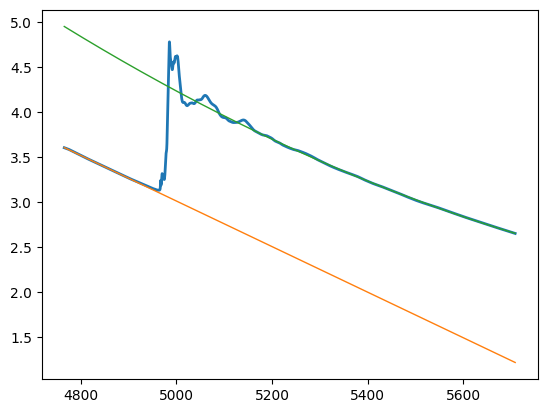

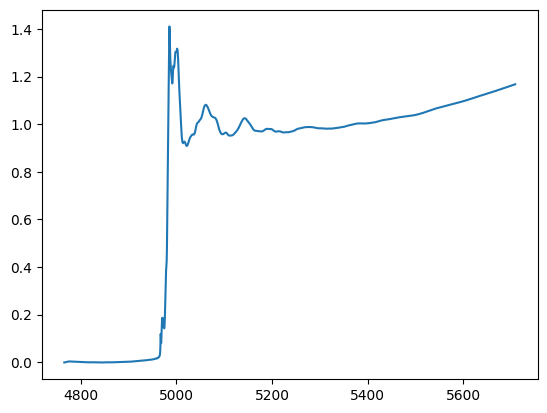

In [44]:
prenorm_spec = parseExptSpectrumXdi("Bruce-prenorm/Ti-K-Anatase.xdi")
norm_spec, pre, post = normalizeSpectrum(prenorm_spec,output_curves=True, preedge_range = (4800,4900), postedge_range = (5200,5600) )
pyplot.plot(prenorm_spec[:,0],prenorm_spec[:,1], lw=2)
pyplot.plot(prenorm_spec[:,0],pre,lw=1)
pyplot.plot(prenorm_spec[:,0],post,lw=1)
pyplot.show()

pyplot.plot(norm_spec[:,0],norm_spec[:,1])
pyplot.show()


Pre-edge fit range 4765.993 4876.002 width 110.00900000000001 degree 1
Post-edge fit range 5007.646 5708.078 width 700.4320000000007 degree 2
Edge step 1.2324233319767117
Post-edge quadratic fit range 5007.646 5708.078 width 700.4320000000007


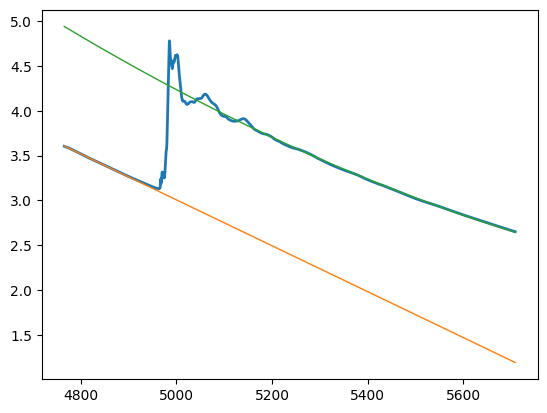

Pre-edge fit range 4765.993 4876.002 width 110.00900000000001 degree 1
Post-edge fit range 5007.646 5708.078 width 700.4320000000007 degree 2
Edge step 1.2324233319767117


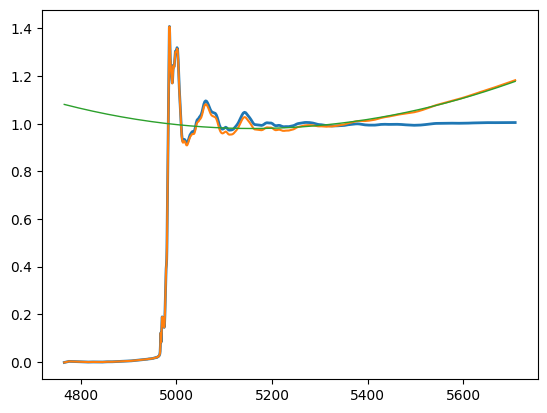

In [45]:
#Test flattening
prenorm_spec = parseExptSpectrumXdi("Bruce-prenorm/Ti-K-Anatase.xdi")
norm_spec, pre, post, flat_quad = normalizeSpectrum(prenorm_spec,output_curves=True, flatten=True )
pyplot.plot(prenorm_spec[:,0],prenorm_spec[:,1], lw=2)
pyplot.plot(prenorm_spec[:,0],pre,lw=1)
pyplot.plot(prenorm_spec[:,0],post,lw=1)
pyplot.show()

norm_spec_noflat = normalizeSpectrum(prenorm_spec)
pyplot.plot(norm_spec[:,0],norm_spec[:,1], lw=2)
pyplot.plot(norm_spec_noflat[:,0],norm_spec_noflat[:,1])
pyplot.plot(norm_spec[:,0],flat_quad, lw=1)
pyplot.show()

Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-CaCe2Ti4O12.xdi
Pre-edge fit range 4765.997 4876.006 width 110.00900000000001 degree 1
Post-edge fit range 5007.644 5708.08 width 700.4359999999997 degree 2
Edge step 1547.4537193992048
Post-edge quadratic fit range 5007.644 5708.08 width 700.4359999999997


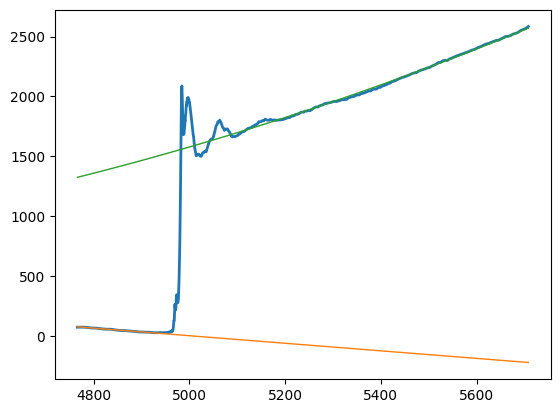

Pre-edge fit range 4765.997 4876.006 width 110.00900000000001 degree 1
Post-edge fit range 5007.644 5708.08 width 700.4359999999997 degree 2
Edge step 1547.4537193992048


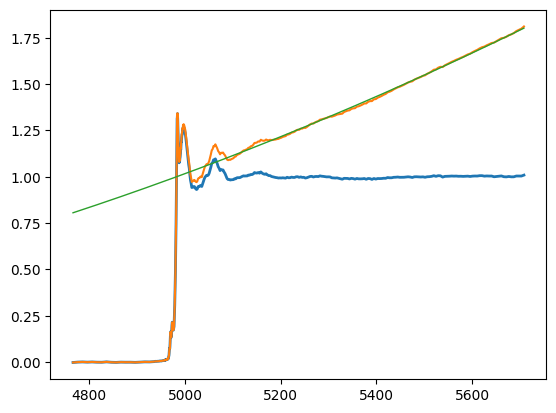



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Rutile.xdi
Pre-edge fit range 4765.985 4876.009 width 110.02400000000034 degree 1
Post-edge fit range 5008.917 5708.08 width 699.1629999999996 degree 2
Edge step 1.6237187898330028
Post-edge quadratic fit range 5008.917 5708.08 width 699.1629999999996


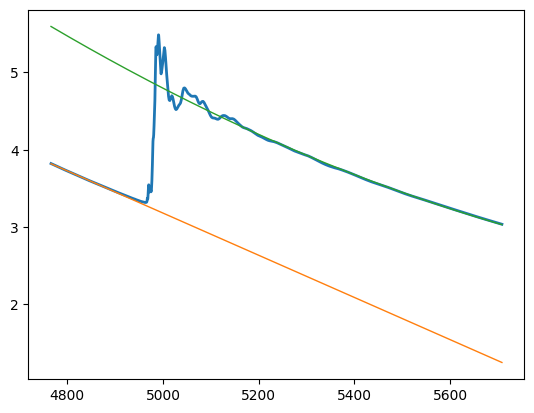

Pre-edge fit range 4765.985 4876.009 width 110.02400000000034 degree 1
Post-edge fit range 5008.917 5708.08 width 699.1629999999996 degree 2
Edge step 1.6237187898330028


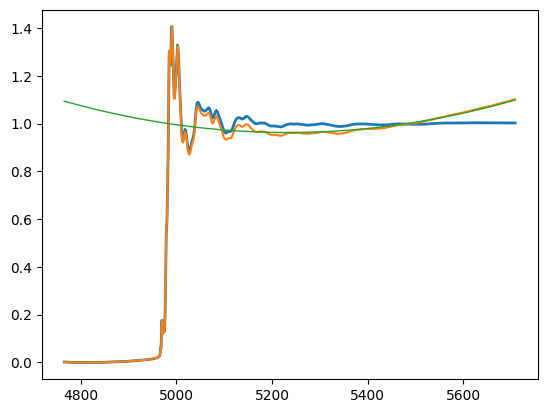



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Anatase.xdi
Pre-edge fit range 4765.993 4876.002 width 110.00900000000001 degree 1
Post-edge fit range 5007.646 5708.078 width 700.4320000000007 degree 2
Edge step 1.2324233319767117
Post-edge quadratic fit range 5007.646 5708.078 width 700.4320000000007


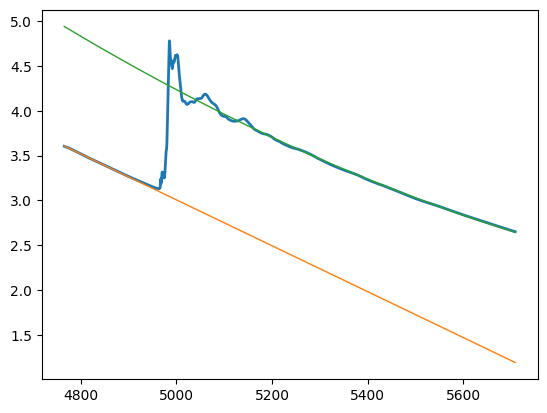

Pre-edge fit range 4765.993 4876.002 width 110.00900000000001 degree 1
Post-edge fit range 5007.646 5708.078 width 700.4320000000007 degree 2
Edge step 1.2324233319767117


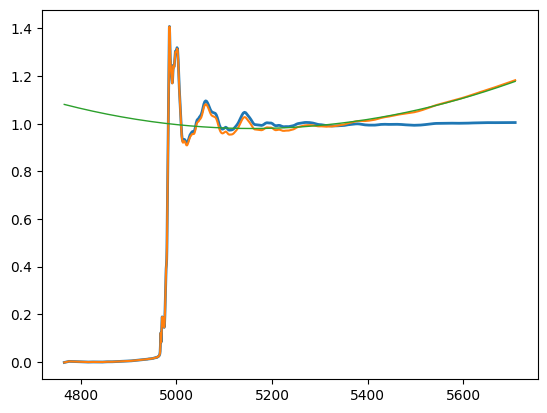



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Gd2TiO5.xdi
Pre-edge fit range 4765.997 4866.008 width 100.01099999999951 degree 1
Post-edge fit range 4993.004 5708.082 width 715.0780000000004 degree 2
Edge step 0.14570946485899405
Post-edge quadratic fit range 4993.004 5708.082 width 715.0780000000004


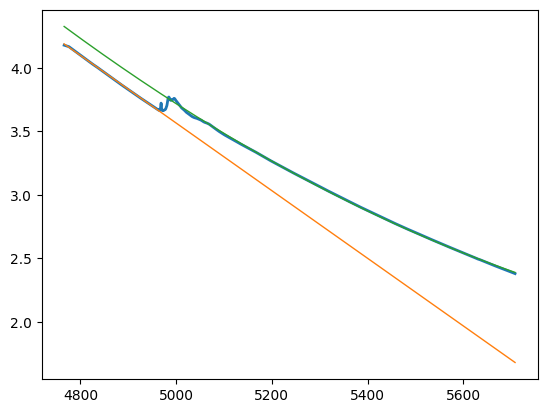

Pre-edge fit range 4765.997 4866.008 width 100.01099999999951 degree 1
Post-edge fit range 4993.004 5708.082 width 715.0780000000004 degree 2
Edge step 0.14570946485899405


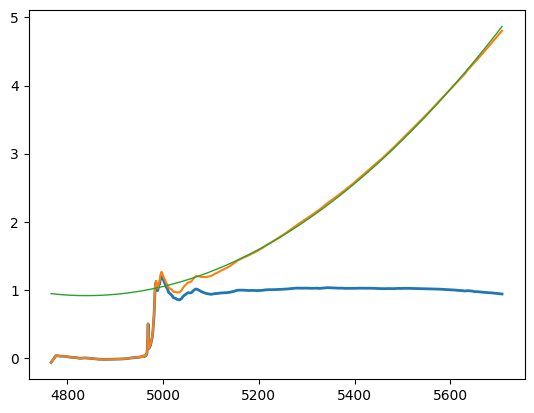



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Eu2Ti2O7.xdi
Pre-edge fit range 4765.994 4876.008 width 110.01400000000012 degree 1
Post-edge fit range 5007.645 5818.23 width 810.5849999999991 degree 2
Edge step 0.2331784857207051
Post-edge quadratic fit range 5007.645 5818.23 width 810.5849999999991


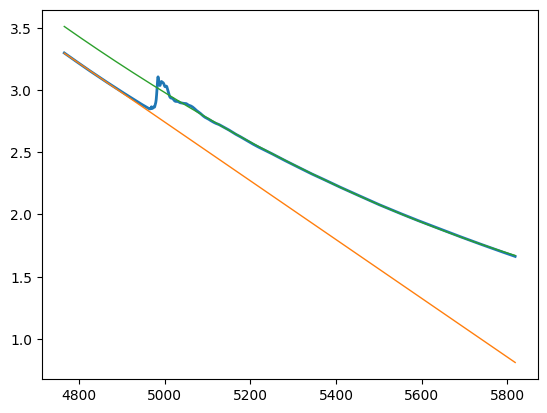

Pre-edge fit range 4765.994 4876.008 width 110.01400000000012 degree 1
Post-edge fit range 5007.645 5818.23 width 810.5849999999991 degree 2
Edge step 0.2331784857207051


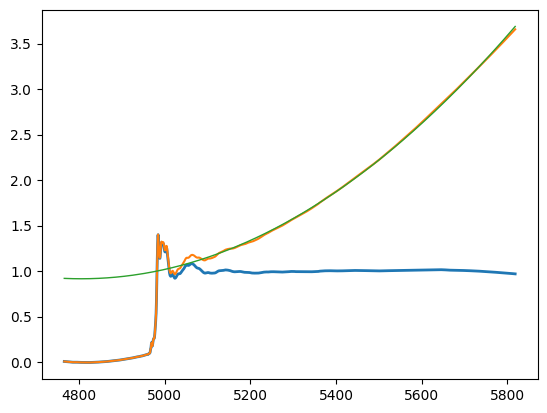



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-CaTiO3.xdi
Pre-edge fit range 4765.984 4876.005 width 110.02099999999973 degree 1
Post-edge fit range 5007.646 5708.081 width 700.4350000000004 degree 2
Edge step 0.3683911445521435
Post-edge quadratic fit range 5007.646 5708.081 width 700.4350000000004


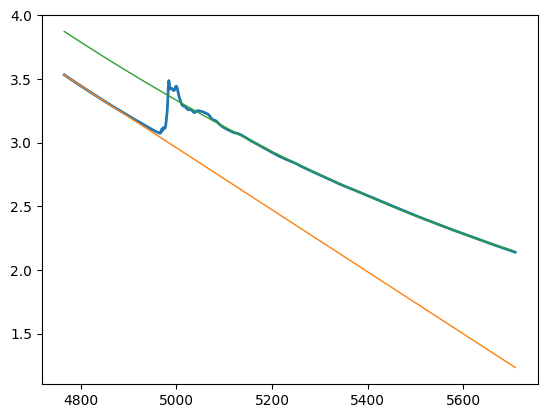

Pre-edge fit range 4765.984 4876.005 width 110.02099999999973 degree 1
Post-edge fit range 5007.646 5708.081 width 700.4350000000004 degree 2
Edge step 0.3683911445521435


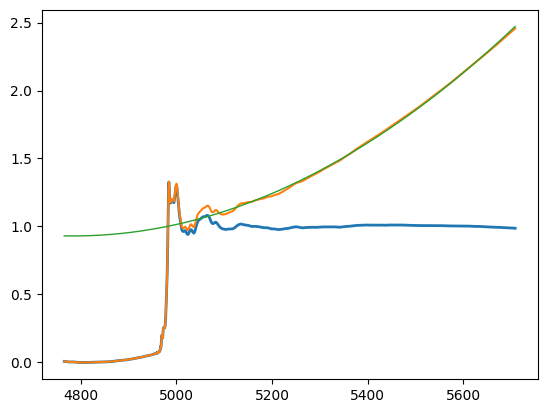



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Brookite.xdi
Pre-edge fit range 4765.995 4876.012 width 110.01699999999983 degree 1
Post-edge fit range 5007.647 5708.082 width 700.4350000000004 degree 2
Edge step 1.103101605271327
Post-edge quadratic fit range 5007.647 5708.082 width 700.4350000000004


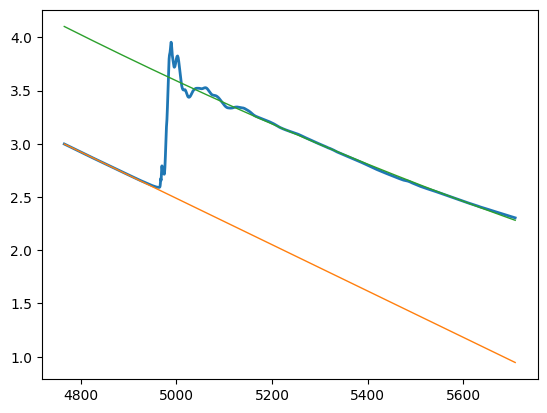

Pre-edge fit range 4765.995 4876.012 width 110.01699999999983 degree 1
Post-edge fit range 5007.647 5708.082 width 700.4350000000004 degree 2
Edge step 1.103101605271327


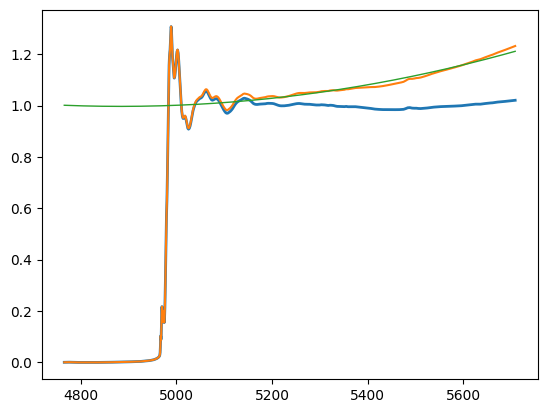



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-EuTiO3.xdi
Pre-edge fit range 4765.994 4876.007 width 110.01299999999992 degree 1
Post-edge fit range 5007.646 5818.231 width 810.585 degree 2
Edge step 0.15973588809066008
Post-edge quadratic fit range 5007.646 5818.231 width 810.585


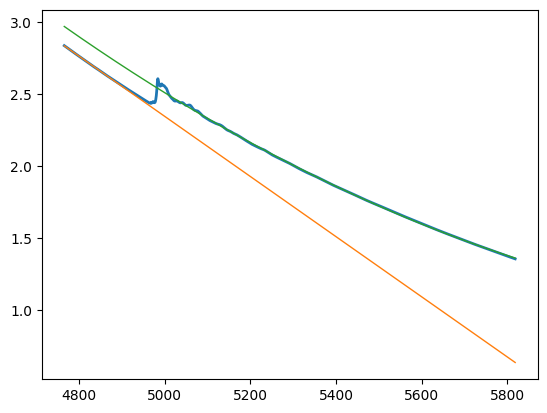

Pre-edge fit range 4765.994 4876.007 width 110.01299999999992 degree 1
Post-edge fit range 5007.646 5818.231 width 810.585 degree 2
Edge step 0.15973588809066008


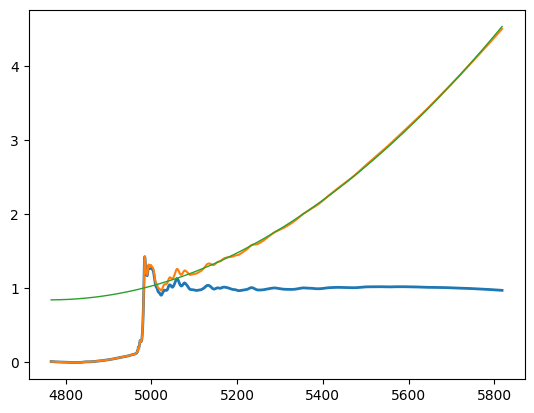



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Titanite.xdi
Pre-edge fit range 4865.992 4926.003 width 60.01099999999951 degree 1
Post-edge fit range 5008.007 5164.002 width 155.9950000000008 degree 1
Edge step 0.10773202672304905
Post-edge quadratic fit range 5008.007 5164.002 width 155.9950000000008


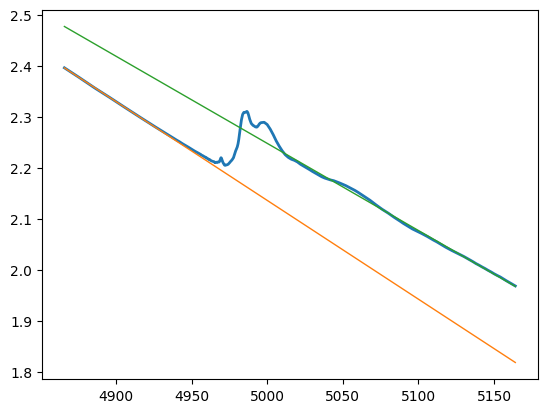

Pre-edge fit range 4865.992 4926.003 width 60.01099999999951 degree 1
Post-edge fit range 5008.007 5164.002 width 155.9950000000008 degree 1
Edge step 0.10773202672304905


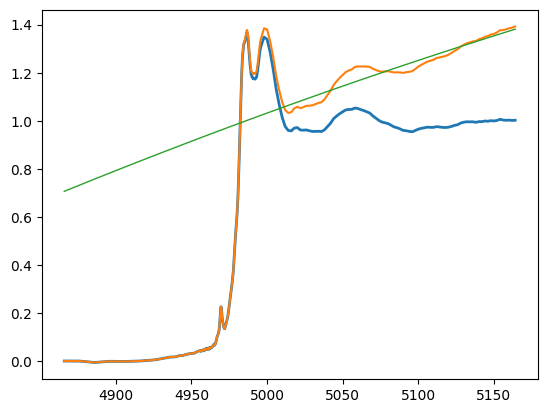



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-CaZrTi2O7.xdi
Pre-edge fit range 4765.997 4876.007 width 110.00999999999931 degree 1
Post-edge fit range 5007.648 5708.082 width 700.4340000000002 degree 2
Edge step 0.20445701056338272
Post-edge quadratic fit range 5007.648 5708.082 width 700.4340000000002


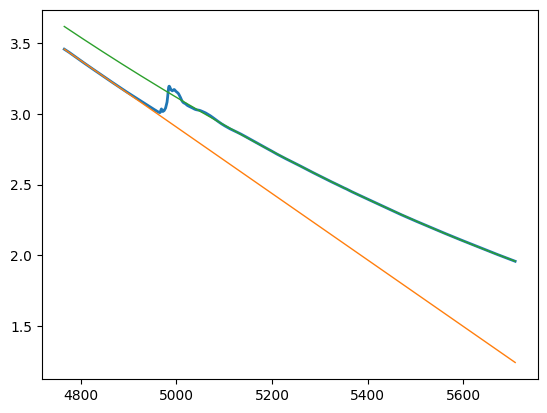

Pre-edge fit range 4765.997 4876.007 width 110.00999999999931 degree 1
Post-edge fit range 5007.648 5708.082 width 700.4340000000002 degree 2
Edge step 0.20445701056338272


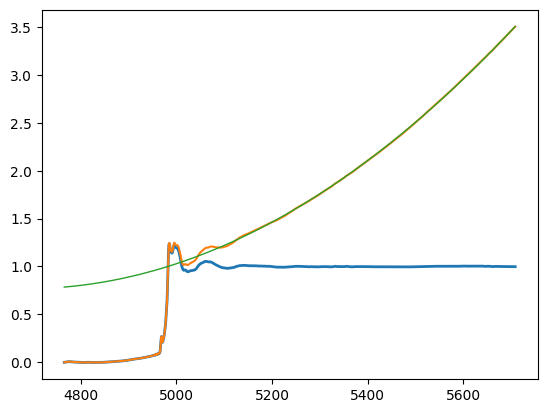



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-BaTiO3.xdi
Pre-edge fit range 4765.982 5006.399 width 240.41700000000037 degree 1
Post-edge fit range 5271.601 5708.08 width 436.47900000000027 degree 2
Edge step 0.23258394871235222
Post-edge quadratic fit range 5271.601 5708.08 width 436.47900000000027


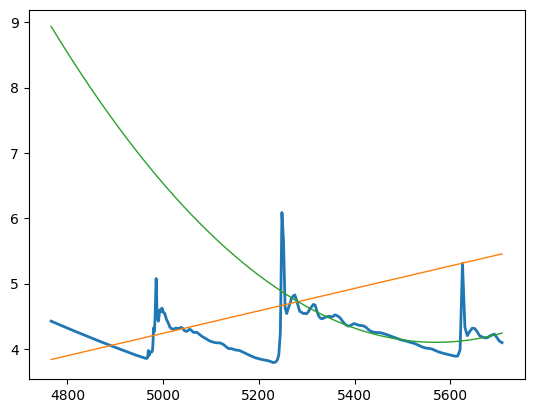

Pre-edge fit range 4765.982 5006.399 width 240.41700000000037 degree 1
Post-edge fit range 5271.601 5708.08 width 436.47900000000027 degree 2
Edge step 0.23258394871235222


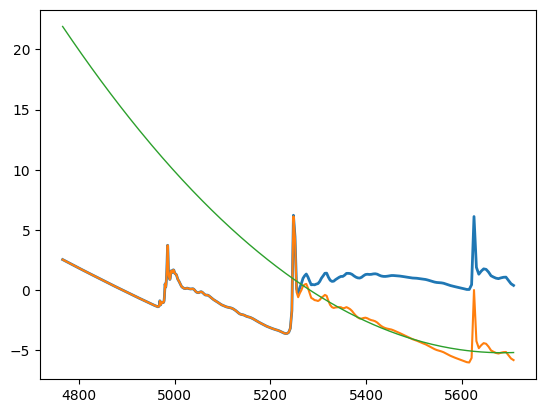



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-BATO16.xdi
Pre-edge fit range 4765.99 4876.002 width 110.01200000000063 degree 1
Post-edge fit range 5002.766 5708.08 width 705.3140000000003 degree 2
Edge step 0.6504007662118347
Post-edge quadratic fit range 5002.766 5708.08 width 705.3140000000003


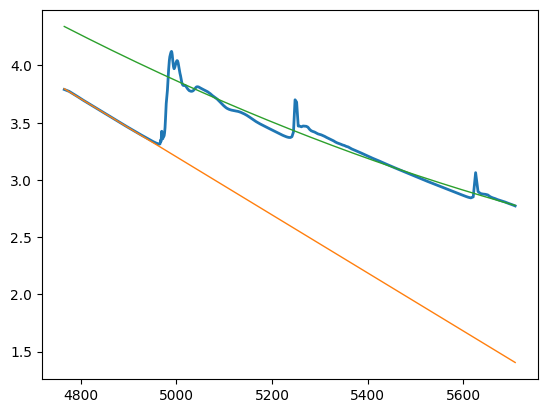

Pre-edge fit range 4765.99 4876.002 width 110.01200000000063 degree 1
Post-edge fit range 5002.766 5708.08 width 705.3140000000003 degree 2
Edge step 0.6504007662118347


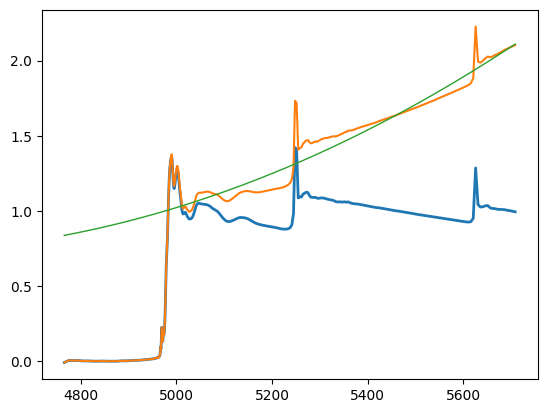



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Ce067TiO3.xdi
Pre-edge fit range 4765.999 4876.005 width 110.00600000000031 degree 1
Post-edge fit range 5006.398 5708.08 width 701.6819999999998 degree 2
Edge step 0.4594166177299748
Post-edge quadratic fit range 5006.398 5708.08 width 701.6819999999998


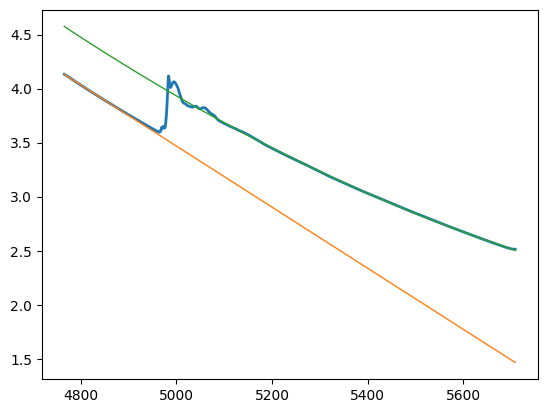

Pre-edge fit range 4765.999 4876.005 width 110.00600000000031 degree 1
Post-edge fit range 5006.398 5708.08 width 701.6819999999998 degree 2
Edge step 0.4594166177299748


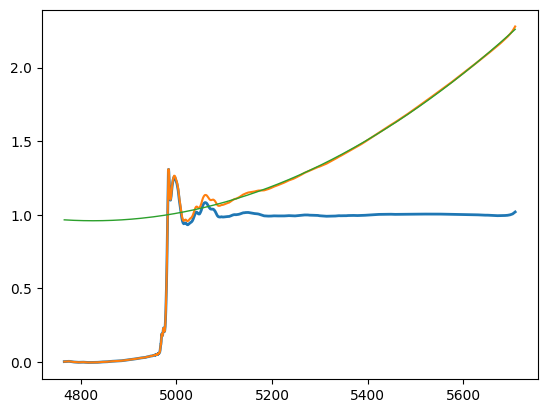



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Ce2Ti2O7.xdi
Pre-edge fit range 4765.991 4876.001 width 110.01000000000022 degree 1
Post-edge fit range 5005.167 5708.08 width 702.9129999999996 degree 2
Edge step 1069.7843153890012
Post-edge quadratic fit range 5005.167 5708.08 width 702.9129999999996


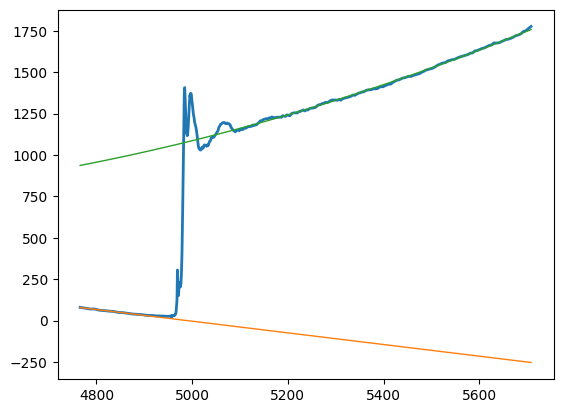

Pre-edge fit range 4765.991 4876.001 width 110.01000000000022 degree 1
Post-edge fit range 5005.167 5708.08 width 702.9129999999996 degree 2
Edge step 1069.7843153890012


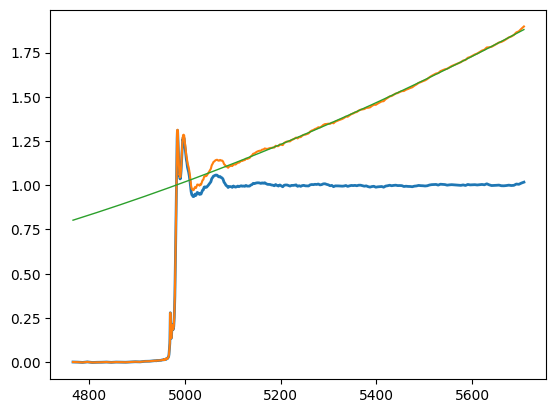



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Fe2TiO5.xdi
Pre-edge fit range 4765.992 4876.005 width 110.01299999999992 degree 1
Post-edge fit range 5006.399 5708.078 width 701.6790000000001 degree 2
Edge step 0.4349190526894855
Post-edge quadratic fit range 5006.399 5708.078 width 701.6790000000001


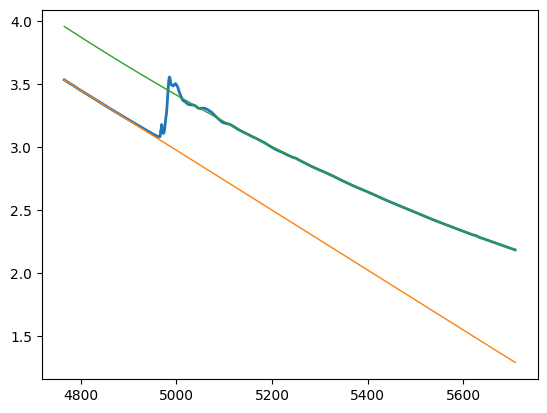

Pre-edge fit range 4765.992 4876.005 width 110.01299999999992 degree 1
Post-edge fit range 5006.399 5708.078 width 701.6790000000001 degree 2
Edge step 0.4349190526894855


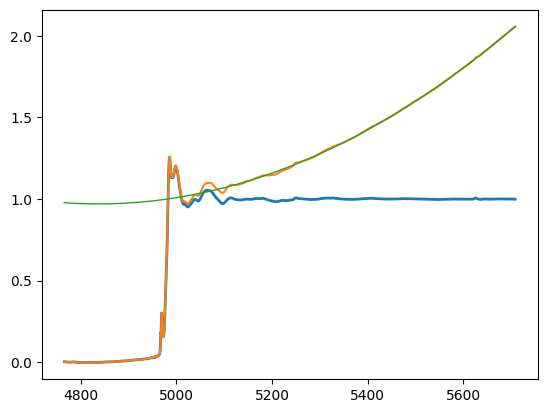



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-SrCe2Ti4O12.xdi
Pre-edge fit range 4765.997 4876.009 width 110.01199999999972 degree 1
Post-edge fit range 5006.399 5708.08 width 701.6809999999996 degree 2
Edge step 1836.3276506065447
Post-edge quadratic fit range 5006.399 5708.08 width 701.6809999999996


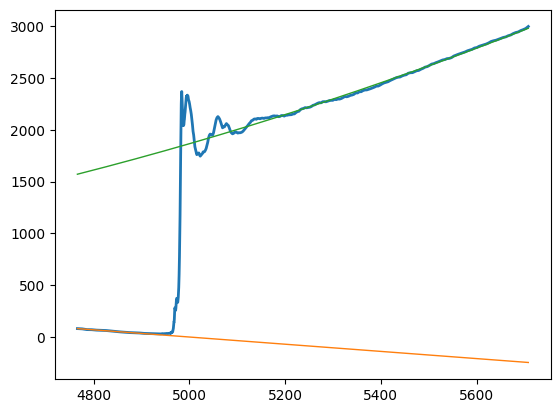

Pre-edge fit range 4765.997 4876.009 width 110.01199999999972 degree 1
Post-edge fit range 5006.399 5708.08 width 701.6809999999996 degree 2
Edge step 1836.3276506065447


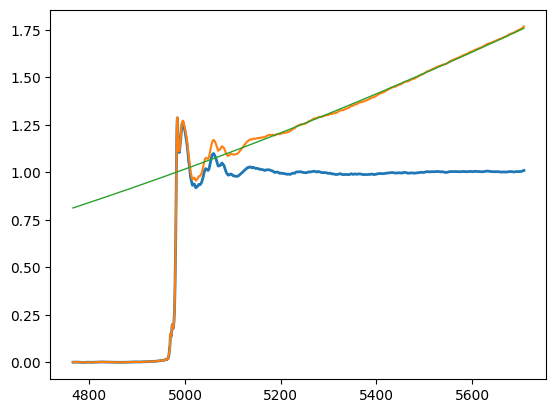



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-TitaniumFoil.xdi
Pre-edge fit range 4766.411 4866.405 width 99.99399999999969 degree 1
Post-edge fit range 4990.304 5819.242 width 828.9380000000001 degree 2
Edge step 1.977225078940858
Post-edge quadratic fit range 4990.304 5819.242 width 828.9380000000001


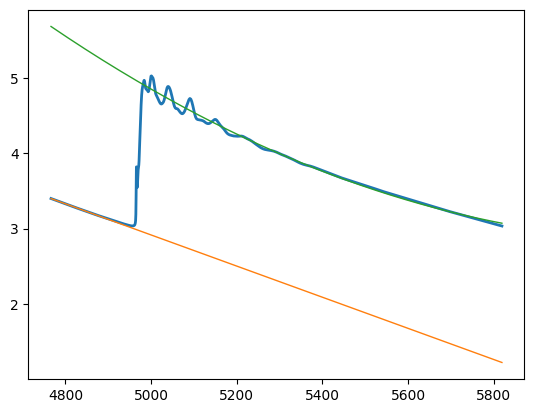

Pre-edge fit range 4766.411 4866.405 width 99.99399999999969 degree 1
Post-edge fit range 4990.304 5819.242 width 828.9380000000001 degree 2
Edge step 1.977225078940858


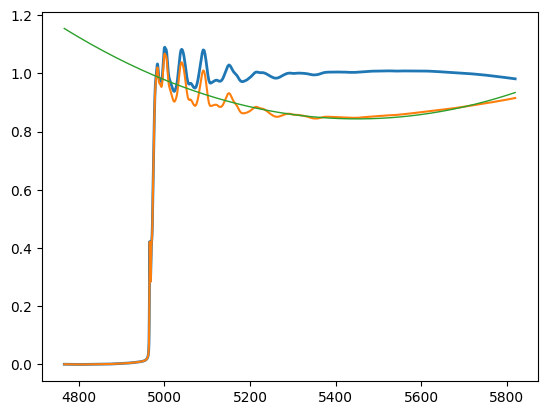



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Bi2Ce2Ti3O12.xdi
Pre-edge fit range 4765.997 4876.01 width 110.01299999999992 degree 1
Post-edge fit range 5006.399 5708.078 width 701.6790000000001 degree 2
Edge step 512.5912037263683
Post-edge quadratic fit range 5006.399 5708.078 width 701.6790000000001


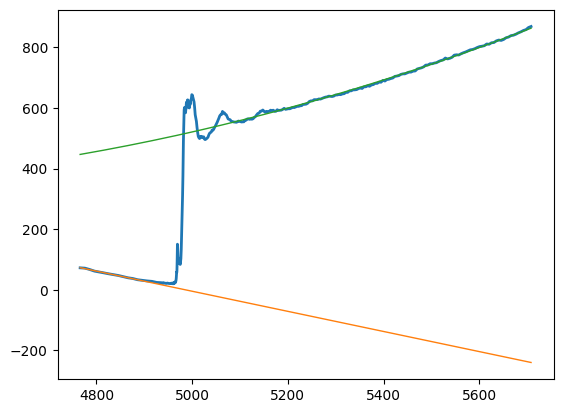

Pre-edge fit range 4765.997 4876.01 width 110.01299999999992 degree 1
Post-edge fit range 5006.399 5708.078 width 701.6790000000001 degree 2
Edge step 512.5912037263683


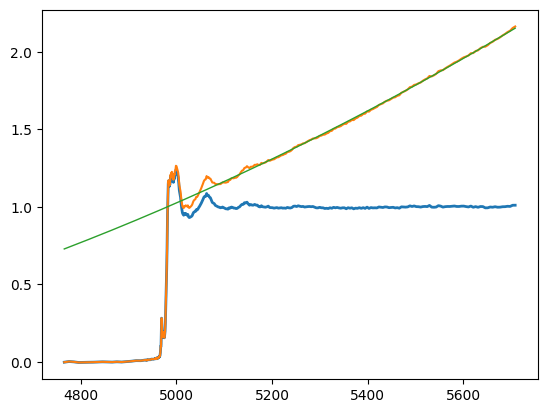



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Ni2TiO4.xdi
Pre-edge fit range 4765.998 4866.004 width 100.00600000000031 degree 1
Post-edge fit range 4992.752 5708.08 width 715.3279999999995 degree 2
Edge step 0.4253684712055268
Post-edge quadratic fit range 4992.752 5708.08 width 715.3279999999995


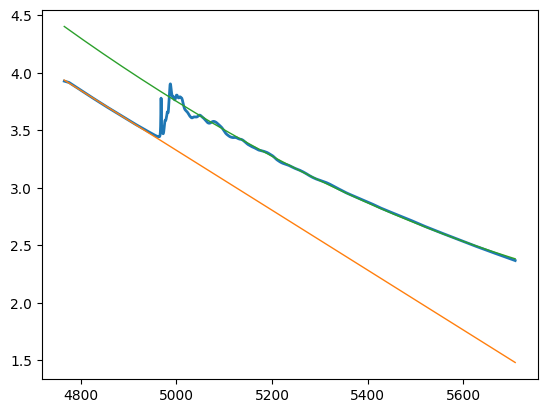

Pre-edge fit range 4765.998 4866.004 width 100.00600000000031 degree 1
Post-edge fit range 4992.752 5708.08 width 715.3279999999995 degree 2
Edge step 0.4253684712055268


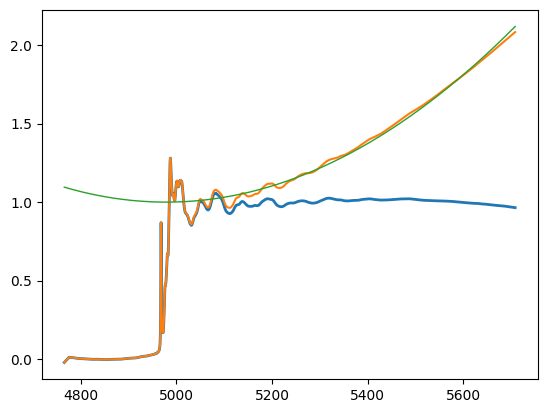



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Gd2TiO7.xdi
Pre-edge fit range 4765.994 4876.01 width 110.01600000000053 degree 1
Post-edge fit range 5006.399 5708.077 width 701.6779999999999 degree 2
Edge step 0.08117047156733115
Post-edge quadratic fit range 5006.399 5708.077 width 701.6779999999999


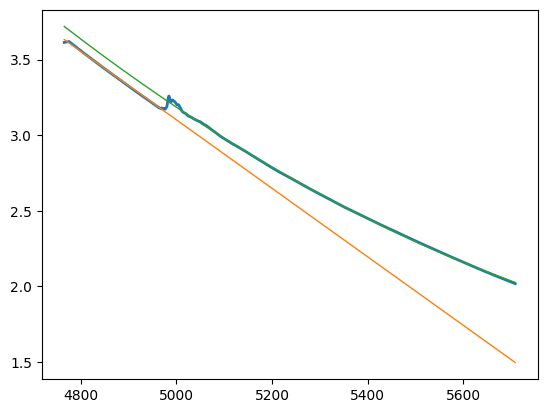

Pre-edge fit range 4765.994 4876.01 width 110.01600000000053 degree 1
Post-edge fit range 5006.399 5708.077 width 701.6779999999999 degree 2
Edge step 0.08117047156733115


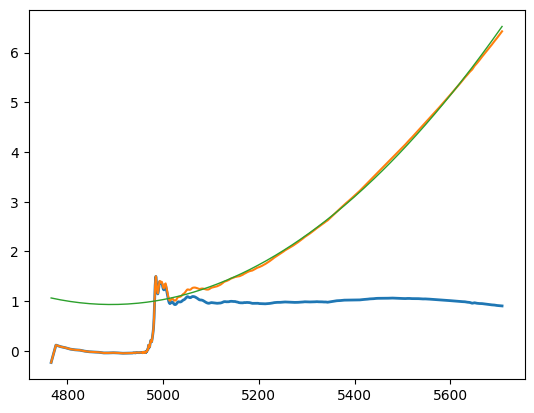



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-CeTi2O6.xdi
Pre-edge fit range 4765.998 4876.005 width 110.00700000000052 degree 1
Post-edge fit range 5007.648 5708.08 width 700.4319999999998 degree 2
Edge step 2100.8316781590074
Post-edge quadratic fit range 5007.648 5708.08 width 700.4319999999998


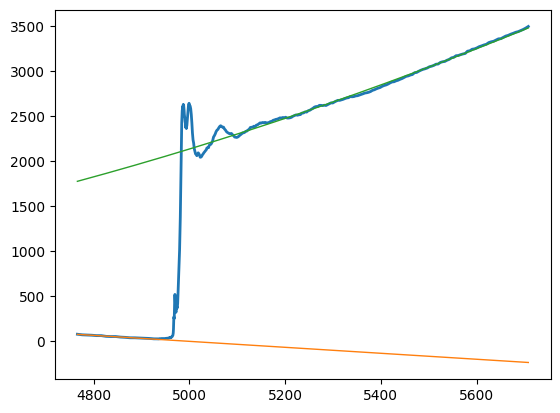

Pre-edge fit range 4765.998 4876.005 width 110.00700000000052 degree 1
Post-edge fit range 5007.648 5708.08 width 700.4319999999998 degree 2
Edge step 2100.8316781590074


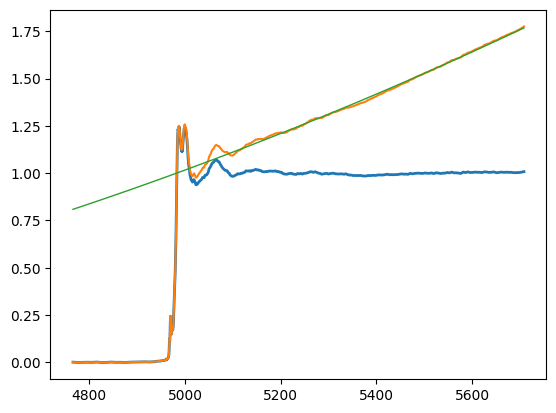



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-TiO.xdi
Pre-edge fit range 4765.997 4866.008 width 100.01099999999951 degree 1
Post-edge fit range 4996.001 5708.078 width 712.0770000000002 degree 2
Edge step 1.3392180267499683
Post-edge quadratic fit range 4996.001 5708.078 width 712.0770000000002


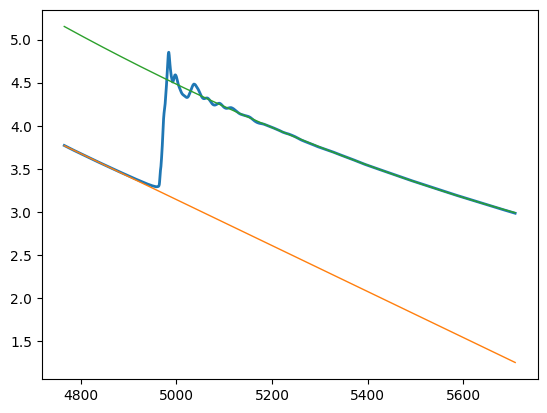

Pre-edge fit range 4765.997 4866.008 width 100.01099999999951 degree 1
Post-edge fit range 4996.001 5708.078 width 712.0770000000002 degree 2
Edge step 1.3392180267499683


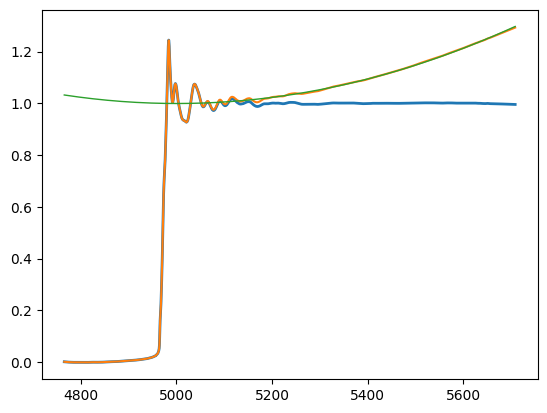



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-NiTiO3.xdi
Pre-edge fit range 4765.98 4866.007 width 100.02700000000004 degree 1
Post-edge fit range 4993.753 5708.078 width 714.3250000000007 degree 2
Edge step 0.5909525967285685
Post-edge quadratic fit range 4993.753 5708.078 width 714.3250000000007


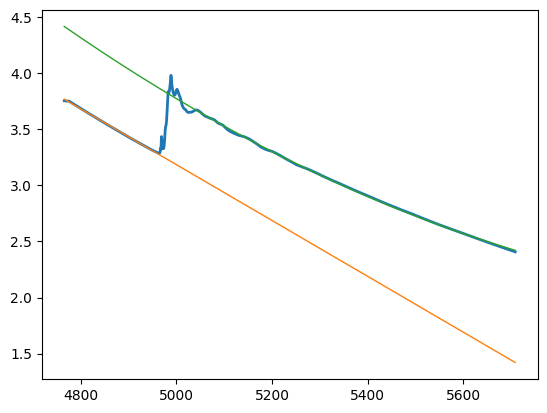

Pre-edge fit range 4765.98 4866.007 width 100.02700000000004 degree 1
Post-edge fit range 4993.753 5708.078 width 714.3250000000007 degree 2
Edge step 0.5909525967285685


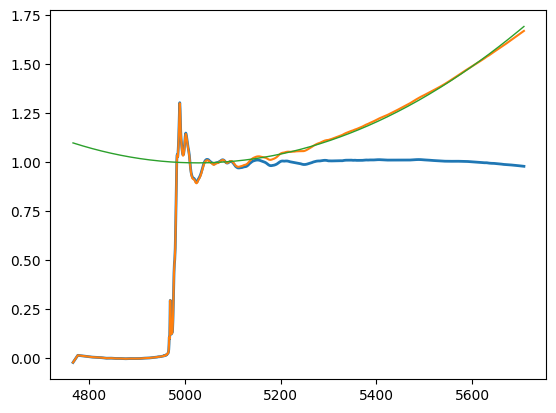



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Na2Ti3O7.xdi
Pre-edge fit range 4765.998 4866.008 width 100.01000000000022 degree 1
Post-edge fit range 4993.751 5708.08 width 714.3289999999997 degree 2
Edge step 0.8134414599600301
Post-edge quadratic fit range 4993.751 5708.08 width 714.3289999999997


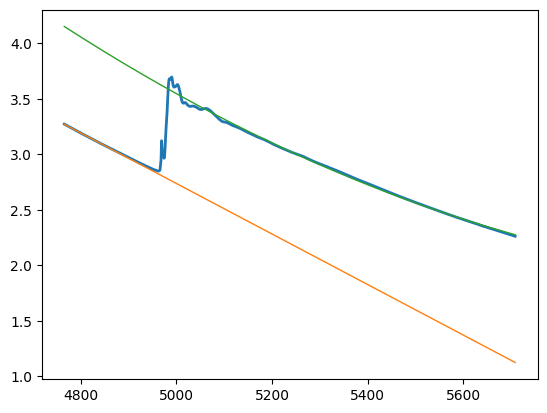

Pre-edge fit range 4765.998 4866.008 width 100.01000000000022 degree 1
Post-edge fit range 4993.751 5708.08 width 714.3289999999997 degree 2
Edge step 0.8134414599600301


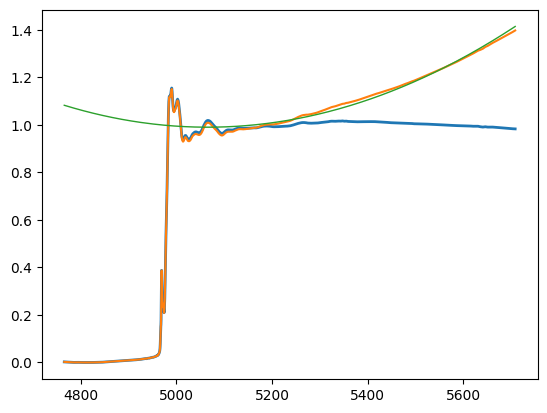



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-FeTiO3.xdi
Pre-edge fit range 4765.98 4866.012 width 100.03200000000015 degree 1
Post-edge fit range 4993.504 5708.078 width 714.5740000000005 degree 2
Edge step 0.8557299751959633
Post-edge quadratic fit range 4993.504 5708.078 width 714.5740000000005


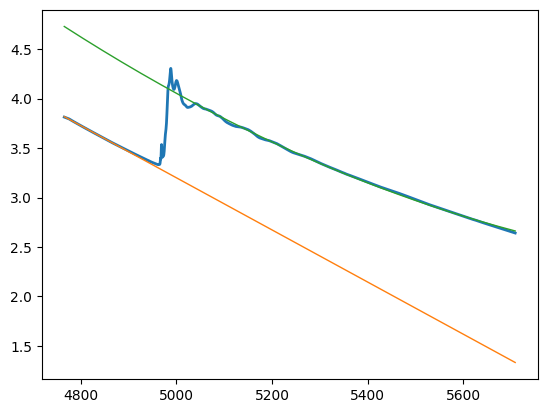

Pre-edge fit range 4765.98 4866.012 width 100.03200000000015 degree 1
Post-edge fit range 4993.504 5708.078 width 714.5740000000005 degree 2
Edge step 0.8557299751959633


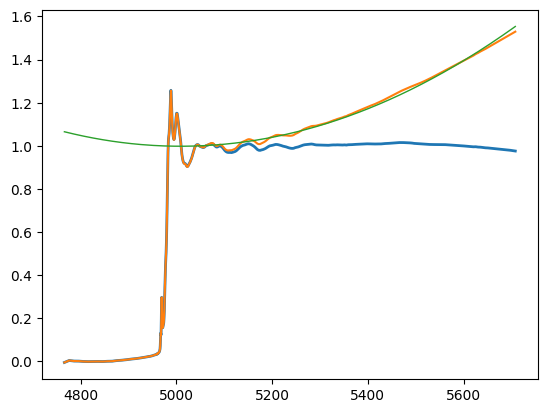



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Nd2Ti2O7.xdi
Pre-edge fit range 4765.991 4876.003 width 110.01199999999972 degree 1
Post-edge fit range 5006.398 5708.077 width 701.6790000000001 degree 2
Edge step 0.14417832887595772
Post-edge quadratic fit range 5006.398 5708.077 width 701.6790000000001


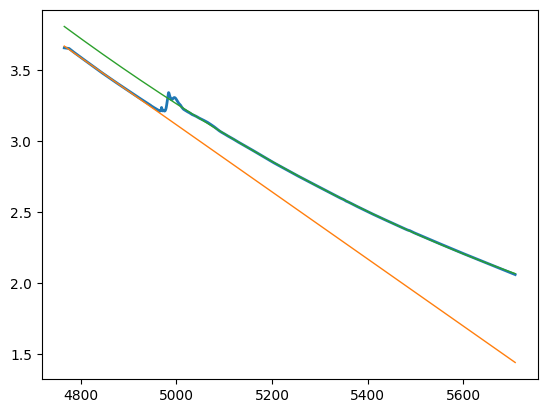

Pre-edge fit range 4765.991 4876.003 width 110.01199999999972 degree 1
Post-edge fit range 5006.398 5708.077 width 701.6790000000001 degree 2
Edge step 0.14417832887595772


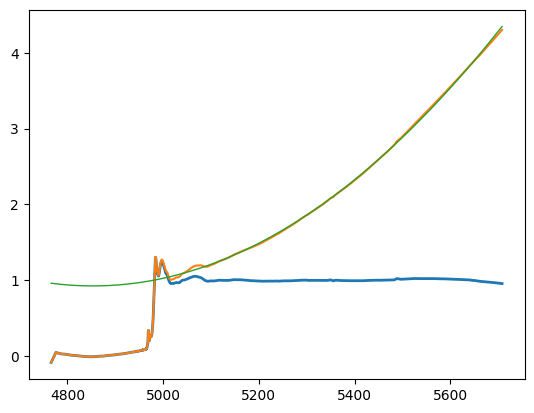



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Ti2O3.xdi
Pre-edge fit range 4765.998 4866.008 width 100.01000000000022 degree 1
Post-edge fit range 4999.296 5708.08 width 708.7839999999997 degree 2
Edge step 1.9431930208318402
Post-edge quadratic fit range 4999.296 5708.08 width 708.7839999999997


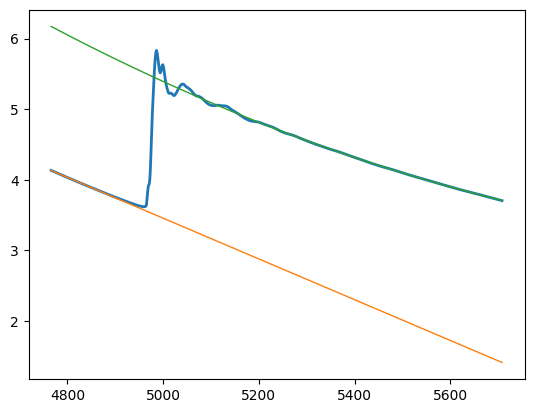

Pre-edge fit range 4765.998 4866.008 width 100.01000000000022 degree 1
Post-edge fit range 4999.296 5708.08 width 708.7839999999997 degree 2
Edge step 1.9431930208318402


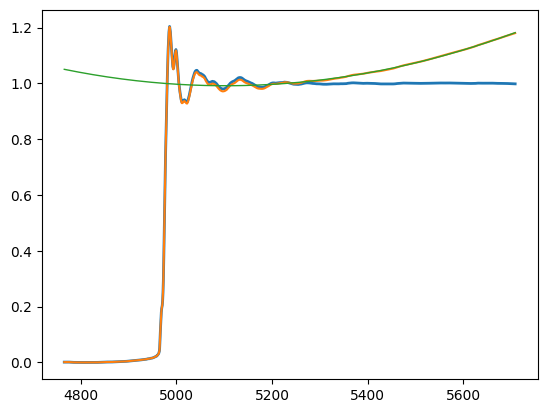



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Dy2TiO5.xdi
Pre-edge fit range 4765.994 4876.006 width 110.01200000000063 degree 1
Post-edge fit range 5007.648 5708.081 width 700.433 degree 2
Edge step 0.09968524247381616
Post-edge quadratic fit range 5007.648 5708.081 width 700.433


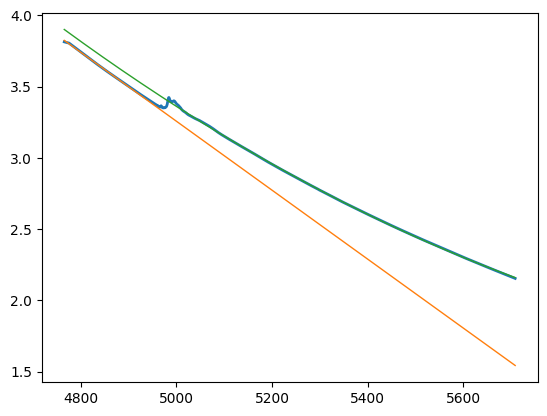

Pre-edge fit range 4765.994 4876.006 width 110.01200000000063 degree 1
Post-edge fit range 5007.648 5708.081 width 700.433 degree 2
Edge step 0.09968524247381616


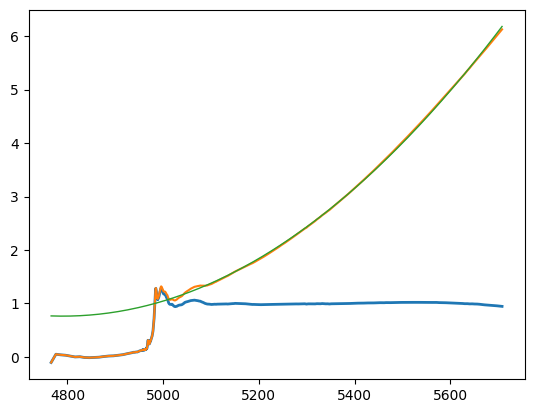



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-TiN.xdi
Pre-edge fit range 4765.993 4876.0 width 110.0069999999996 degree 1
Post-edge fit range 5005.163 5818.228 width 813.0650000000005 degree 2
Edge step 0.3403433746481035
Post-edge quadratic fit range 5005.163 5818.228 width 813.0650000000005


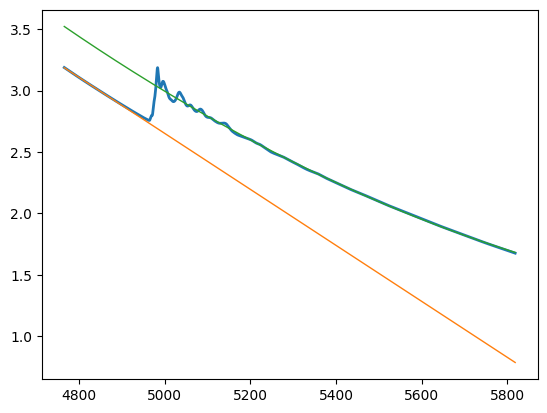

Pre-edge fit range 4765.993 4876.0 width 110.0069999999996 degree 1
Post-edge fit range 5005.163 5818.228 width 813.0650000000005 degree 2
Edge step 0.3403433746481035


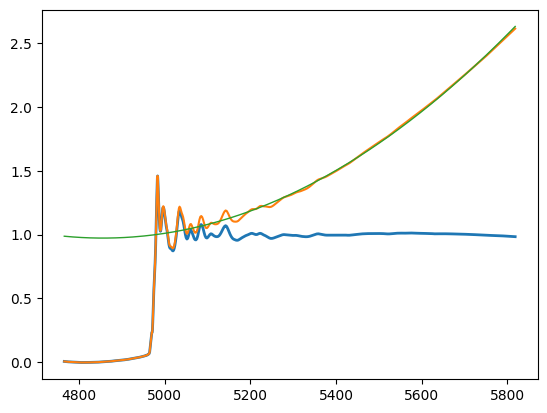



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-SrTiO3.xdi
Pre-edge fit range 4765.982 4876.01 width 110.02800000000025 degree 1
Post-edge fit range 5006.398 5708.08 width 701.6819999999998 degree 2
Edge step 0.4213026193943161
Post-edge quadratic fit range 5006.398 5708.08 width 701.6819999999998


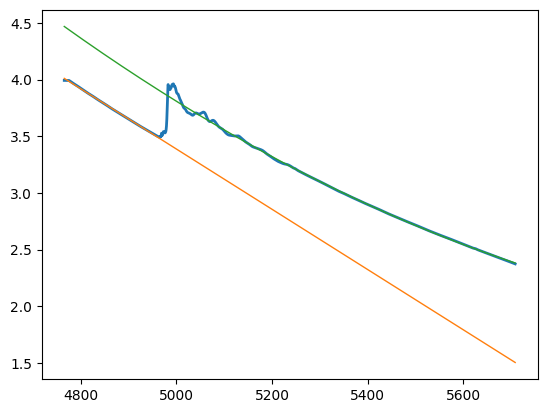

Pre-edge fit range 4765.982 4876.01 width 110.02800000000025 degree 1
Post-edge fit range 5006.398 5708.08 width 701.6819999999998 degree 2
Edge step 0.4213026193943161


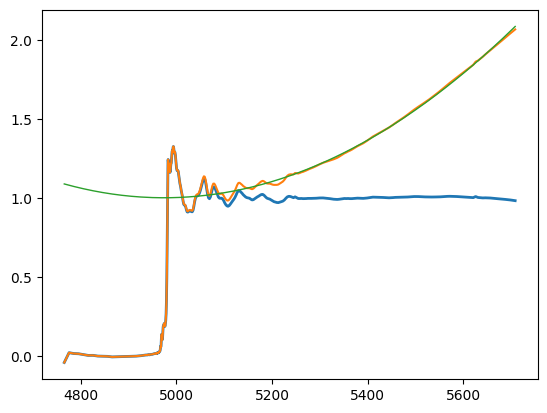



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Fresnoite.xdi
Pre-edge fit range 4765.989 5006.397 width 240.40800000000036 degree 1
Post-edge fit range 5271.602 5708.082 width 436.4800000000005 degree 2
Edge step 0.6087255758394532
Post-edge quadratic fit range 5271.602 5708.082 width 436.4800000000005


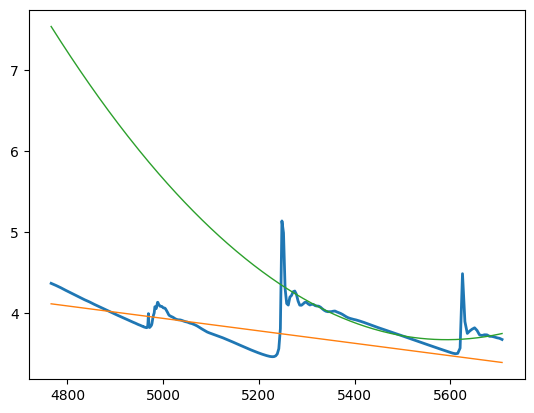

Pre-edge fit range 4765.989 5006.397 width 240.40800000000036 degree 1
Post-edge fit range 5271.602 5708.082 width 436.4800000000005 degree 2
Edge step 0.6087255758394532


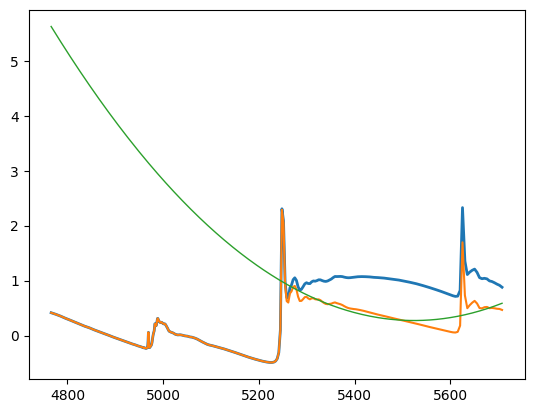



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Ce23TiO3.xdi
Pre-edge fit range 4765.993 4876.005 width 110.01199999999972 degree 1
Post-edge fit range 5005.168 5708.08 width 702.9120000000003 degree 2
Edge step 1401.029865055822
Post-edge quadratic fit range 5005.168 5708.08 width 702.9120000000003


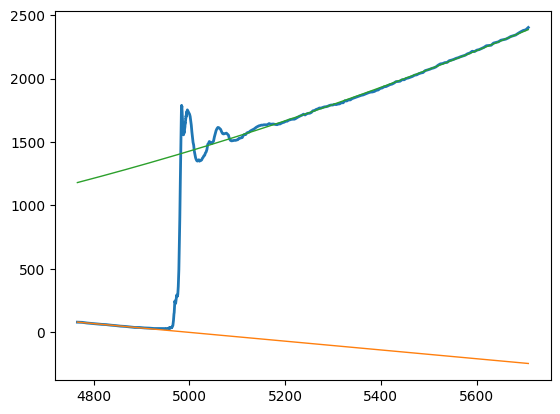

Pre-edge fit range 4765.993 4876.005 width 110.01199999999972 degree 1
Post-edge fit range 5005.168 5708.08 width 702.9120000000003 degree 2
Edge step 1401.029865055822


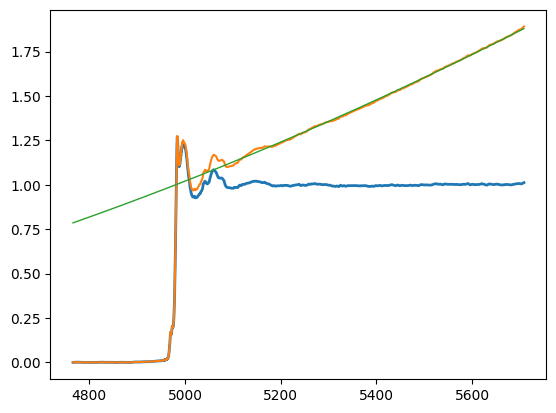



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-Li2TiO5.xdi
Pre-edge fit range 4765.995 4866.012 width 100.01699999999983 degree 1
Post-edge fit range 5000.438 5818.231 width 817.7929999999997 degree 2
Edge step 1.0787580243916395
Post-edge quadratic fit range 5000.438 5818.231 width 817.7929999999997


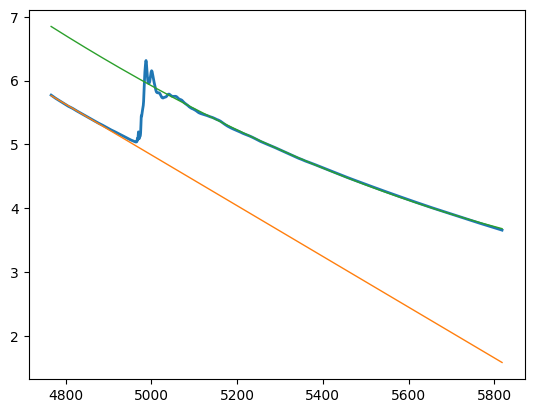

Pre-edge fit range 4765.995 4866.012 width 100.01699999999983 degree 1
Post-edge fit range 5000.438 5818.231 width 817.7929999999997 degree 2
Edge step 1.0787580243916395


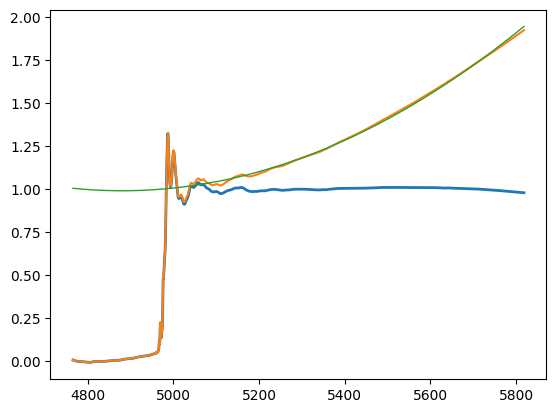



Bruce-prenorm/bmm-standards/Data/Ti/Ti-K-BFTO16.xdi
Pre-edge fit range 4765.998 5006.397 width 240.39900000000034 degree 1
Post-edge fit range 5271.598 5708.08 width 436.48199999999997 degree 2
Edge step 0.6049898017878315
Post-edge quadratic fit range 5271.598 5708.08 width 436.48199999999997


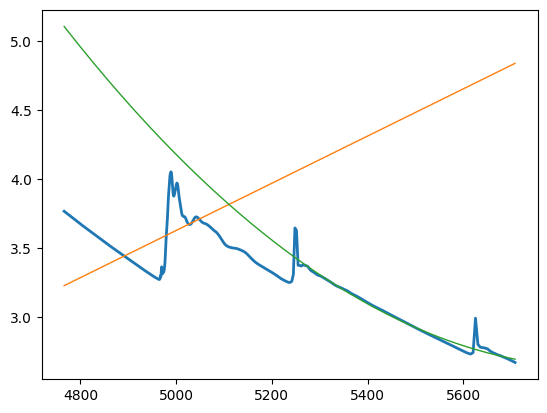

Pre-edge fit range 4765.998 5006.397 width 240.39900000000034 degree 1
Post-edge fit range 5271.598 5708.08 width 436.48199999999997 degree 2
Edge step 0.6049898017878315


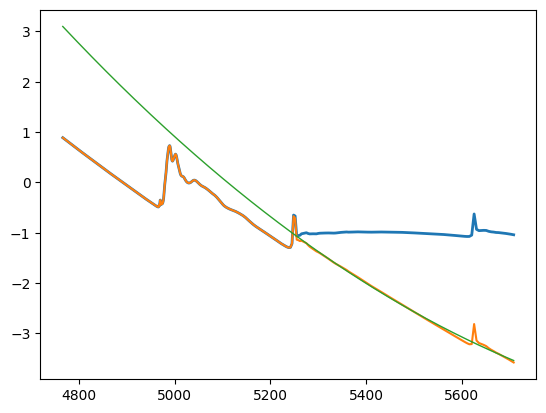

In [46]:
#Test flattening for a bunch of other data
import glob
files = glob.glob("Bruce-prenorm/bmm-standards/Data/Ti/*.xdi")

for f in files:
    print(f)
    prenorm_spec = parseExptSpectrumXdi(f)
    norm_spec, pre, post, flat_quad = normalizeSpectrum(prenorm_spec,output_curves=True,flatten=True)
    pyplot.plot(prenorm_spec[:,0],prenorm_spec[:,1], lw=2)
    pyplot.plot(prenorm_spec[:,0],pre,lw=1)
    pyplot.plot(prenorm_spec[:,0],post,lw=1)
    pyplot.show()

    norm_spec_noflat = normalizeSpectrum(prenorm_spec)
    pyplot.plot(norm_spec[:,0],norm_spec[:,1], lw=2)
    pyplot.plot(norm_spec_noflat[:,0],norm_spec_noflat[:,1])
    pyplot.plot(norm_spec[:,0],flat_quad, lw=1)
    pyplot.show()
    
    print("================\n\n")